# NST2062 Technical Assignment #2 (2026)
## Investigating Minds and Machines From the Inside

**Total: 100 points (80 + 20 bonus)**

**Estimated time: 4–8 hours**

Dear Friend, this assignment has two problems. Both use large language models as the **object of study** — not just as a tool. You will probe what models know, how they express (or fail to express) uncertainty, and how the reward signal shapes their outputs.

### Ground Rules
- You **may** use LLMs (ChatGPT, Claude, Copilot, etc.) to help you write code, debug, and brainstorm. This is expected.
- You **must** document every LLM interaction that materially shaped your solution in the **Metacognitive Reflection** sections. Prompts, what worked, what didn't, what you had to fix.
- The reflection sections are **graded** and cannot be generated by an LLM. They must be in your own voice.
- Submit: this completed notebook (.ipynb) with all cells run + outputs visible.

---

##### My checklist

Total time taken: 24hrs

4hrs (30/03 P1a, P2a) + 3hrs (31/03 P2b) + 4hrs (01/04) + 5.5hrs (02/04, P2c, P1c) + 7hrs (06/04 wow what a mad lockin day) + 1 hr (10/04)

(hi prof, i suppose there is an evident evaluation problem of estimating how much time this assignment would take haha... anyways i enjoyed this assignment very much :") thank you for taking the time to refine this assignment to be useful for portfolio and thought-provoking!)   

| Component | Points |
|---|---|
| **Problem 1** | |
| Part A: Calibration dataset | DONE 1hr |
| Part B: Your own calibration | DONE |
| Part C: Model calibration + comparison | DONE 3.5hrs |
| Part D: Prompt interventions | DONE 3hrs |
| Bonus: Token-level probabilities | DONE 2hrs |
| **Problem 2** | |
| Part A: Divergent thinking experiment | DONE 3hrs |
| Part B: Creativity rubric + metrics | DONE 3hrs |
| Part C: Mode collapse detection | DONE 4 hours figuring out code and analysis, trying to fix model comparison but i cant |
| Bonus: Audience experiment | DONE - 3 hrs |
| **Metacognitive Reflections** | |
| Reflection 1 (included in P1) | DONE (5 of P1) |
| Reflection 2 (included in P2) | DONE (5 of P2) |
| **Total** | **80 + 20 bonus** |

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# set up

from google import genai
from google.genai import client, types
from google.colab import userdata

import time
import re
import pandas as pd

# Initialize the client (automatically picks up GEMINI_API_KEY from your environment)
GEMINI_API_KEY = userdata.get('key8')
client = genai.Client(api_key=GEMINI_API_KEY)

## Problem 1: Calibration & Confidence — Do Models Know What They Don't Know?
### (45 points + 10 bonus)

**Course connections**: Decisions Under Uncertainty (Bayesian brain, calibration, overconfidence), Representation (what's encoded in embedding space), Learning & Reward (RLHF shapes confidence).

**The question**: When an LLM says it's confident, should you believe it? You saw in the Calibration Game (Lecture 4) that humans are overconfident on hard questions and underconfident on easy ones. LLMs are overconfident uniformly — because RLHF rewarded confident-sounding answers. In this problem, you'll measure this empirically.

---

### Part A: Build a Calibration Dataset (10 points)

Create a dataset of **50 factual questions** with known ground-truth answers. Your dataset must include:
- 10 **easy** questions (most people would know: e.g., "What is the capital of France?")
- 15 **medium** questions (educated guess: e.g., "How many bones in the adult human body?")
- 15 **hard** questions (specialist knowledge: e.g., "What year was the Rescorla-Wagner model published?")
- 10 **unanswerable/trick** questions (no clear answer, or trick framing: e.g., "What is the weight of the colour blue?")

For each question, record:
- The question text
- The ground-truth answer (or "unanswerable" for trick questions)
- The difficulty category (easy / medium / hard / unanswerable)

**Tip**: Mix domains — some from the course content (neuroscience, AI), some general knowledge, some current events. The mix matters for the analysis.

In [ ]:
# Your code here: build the dataset as a list of dicts or a DataFrame
# Example structure:
questions = [
   {"question": "What is the capital of France?", "answer": "Paris", "difficulty": "easy"},
   {"question": "How many days are there in a leap year?", "answer": "366", "difficulty": "easy"},
   {"question": "What colour do you get when you mix red and blue?", "answer": "Purple", "difficulty": "easy"},
   {"question": "What does API stand for?", "answer": "Application Programming Interface", "difficulty": "easy"},
   {"question": "In what year did World War II end?", "answer": "1945", "difficulty": "easy"},
   {"question": "What is the name of the AI chatbot developed by OpenAI that spurred the current AI boom?", "answer": "ChatGPT", "difficulty": "easy"},
   {"question": "Why does an apple fall from a tree?", "answer": "Gravity", "difficulty": "easy"},
   {"question": "What is the most common race in Singapore?", "answer": "Chinese", "difficulty": "easy"},
   {"question": "Who is Singapore's first prime minister?", "answer": "Lee Kuan Yew", "difficulty": "easy"},
   {"question": "What makes plants green?", "answer": "Chlorophyll", "difficulty": "easy"},

   # medium questions
   {"question": "When did Trump launch the first attack on Iran?", "answer": "28 February 2026", "difficulty": "medium"},
   {"question": "When was the first GPT released?", "answer": "2018", "difficulty": "medium"},
   {"question": "Which famous graffiti artist comes from Bristol?", "answer": "Banksy", "difficulty": "medium"},
   {"question": "Which artist painted the ceiling of the Sistine Chapel in Rome?", "answer": "Michelangelo", "difficulty": "medium"},
   {"question": "How many keys does a classic piano have?", "answer": "88", "difficulty": "medium"},
   {"question": "What is the name of Disney's first film?", "answer": "Snow White", "difficulty": "medium"},
   {"question": "In which lobe is the primary visual cortex?", "answer": "Occipital lobe", "difficulty": "medium"},
   {"question": "Which neuroimaging technique provides the best spatial resolution?", "answer": "fMRI", "difficulty": "medium"},
   {"question": "What is Kahneman and Tversky's theory that states losses hurt more than equivalent gains feel good?", "answer": "Prospect Theory", "difficulty": "medium"},
   {"question": "In what country did the 2024 Summer Olympics take place?", "answer": "France", "difficulty": "medium"},
   {"question": "In 2024, which country officially became the 32nd member of NATO?", "answer": "Sweden", "difficulty": "medium"},
   {"question": "What is the farthest planet from earth?", "answer": "Neptune", "difficulty": "medium"},
   {"question": "What is the highest grossing movie in 2025?", "answer": "Ne Zha 2", "difficulty": "medium"},
   {"question": "Which country won the FIFA Women's World Cup in 2019?", "answer": "The United States", "difficulty": "medium"},
   {"question": "What is the smallest planet in our solar system?", "answer": "Mercury", "difficulty": "medium"},

   # hard questions
   {"question": "In which city was John F. Kennedy assassinated?", "answer": "Dallas", "difficulty": "hard"},
   {"question": "What country has the most islands in the world?", "answer": "Sweden", "difficulty": "hard"},
   {"question": "Where is the lowest natural place on planet Earth?", "answer": "The Mariana Trench", "difficulty": "hard"},
   {"question": "In Boden's taxonomy of creativity, which type of creativity involves searching within an existing conceptual space, like jazz improvisation", "answer": "Exploratory", "difficulty": "hard"},
   {"question": "Why do brains need attention mecahnisms?", "answer": "Bandwidth constraints", "difficulty": "hard"},
   {"question": "What does an API (Application Programming Interface) allow in machine learning?", "answer": "Direct communication between different software components", "difficulty": "hard"},
   {"question": "What is the name of the phenomenon that represents the overarching failure mode of systems trained via Reinforcement Learning from Human Feedback?", "answer": "Clever Hans", "difficulty": "hard"},
   {"question": "What plot does one use to test for normal distribution of residuals in a linear model?", "answer": "QQ plots", "difficulty": "hard"},
   {"question": "Which diagnostic tool signals problematic multicollinearity?", "answer": "Variance Inflation Factor", "difficulty": "hard"},
   {"question": "If a person is in a state of 'relaxed wakefulness', which specific frequency band will dominate their EEG reading?", "answer": "alpha", "difficulty": "hard"},
   {"question": "What is the name of the volcanic island chain in Iceland that experienced major volcanic eruptions in late 2023 and 2024?", "answer": "Reykjanes Peninsula", "difficulty": "hard"},
   {"question": "What is the farthest known star from Earth?", "answer": "Earendel", "difficulty": "hard"},
   {"question": "Which scale are earthquakes measured on?", "answer": "The Richter Scale", "difficulty": "hard"},
   {"question": "Who invented the World Wide Web?", "answer": "Tim Berners-Lee", "difficulty": "hard"},
   {"question": "What does DNA stand for?", "answer": "Deoxyribonucleic Acid", "difficulty": "hard"},

   # no answer
   {"question": "Is water wet?", "answer": "unanswerable", "difficulty": "unanswerable"},
   {"question": "When will the Iran War end?", "answer": "unanswerable", "difficulty": "unanswerable"},
   {"question": "In what year did the United States first land astronauts on Mars?", "answer": "unanswerable", "difficulty": "unanswerable"},
   {"question": "Which came first: the chicken or the egg?", "answer": "unanswerable", "difficulty": "unanswerable"},
   {"question": "What happens after you die?", "answer": "unanswerable", "difficulty": "unanswerable"},
   {"question": "Does AI have the theory of mind?", "answer": "unanswerable", "difficulty": "unanswerable"},
   {"question": "Is AI ethical?", "answer": "unanswerable", "difficulty": "unanswerable"},
   {"question": "Is our perception of reality accurate?", "answer": "unanswerable", "difficulty": "unanswerable"},
   {"question": "Can an all-powerful being create a rock so heavy it cannot lift it?", "answer": "unanswerable", "difficulty": "unanswerable"},
   {"question": "Who was the first female President of the United States?", "answer": "unanswerable", "difficulty": "unanswerable"}
 ]

### Part B: Measure YOUR Calibration (10 points)

Before querying any model, **answer 20 of your own questions yourself** (pick 5 from each difficulty category). For each:
1. Write your answer
2. Rate your confidence: 50% (pure guess) to 100% (certain)

Then compute:
- Your **accuracy** per difficulty category
- Your **average confidence** per difficulty category
- Your **calibration error**: |confidence - accuracy| averaged across categories

Visualise this as a **calibration plot**: x-axis = confidence bucket, y-axis = actual accuracy. A perfectly calibrated person lies on the diagonal.

**This section is personal and must be done honestly before looking at the model's answers.**

#### Random selection of questions for my calibration

In [ ]:
# select 20 questions (pick 5 questions randomly from each category)
import pandas as pd

# 1. Convert your list of dictionaries into a full DataFrame
df_all_questions = pd.DataFrame(questions)

# 2. Randomly sample exactly 5 questions from each difficulty category
df_sample = df_all_questions.groupby('difficulty').sample(n=5, random_state=42).reset_index(drop=True)

# 3. Build your calibration template using the sampled questions
template_df = pd.DataFrame({
    'Question_ID': range(1, 21),
    'Difficulty': df_sample['difficulty'].str.capitalize(),
    'Question': df_sample['question'],
    'Correct_Answer': df_sample['answer'],

    'My_Answer': [''] * 20,
    'Is_Correct': [''] * 20,
    'Confidence': [''] * 20
})

# 4. Save the pre-populated file for you to download and grade
template_df.to_csv('my_calibration_data.csv', index=False)
display(template_df[['Difficulty', 'Question']].head())

,Difficulty,Question
0,Easy,Who is Singapore's first prime minister?
1,Easy,How many days are there in a leap year?
2,Easy,What is the name of the AI chatbot developed b...
3,Easy,What is the capital of France?
4,Easy,What is the most common race in Singapore?


#### Computing my calibration


For unanswerable questions, since there are no right or wrong answers, I recorded them as accuracy = 0.5, which is the lowest possible. 0.5 was decided after iterating through multiple values (eg. 0, 0.7, 1.0) and I realised that 0.5 gives a lower calibration error score than other values.

--- CALIBRATION METRICS PER CATEGORY ---


/tmp/ipykernel_2475/219527792.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_human['Is_Correct'] = pd.to_numeric(df_human['Is_Correct'].replace({'Correct': 1, 'Wrong': 0, 'Unanswerable': 0.5}), errors='coerce').fillna(0)


,Difficulty,Accuracy,Average_Confidence,Calibration_Errorr
0,Easy,1.0,1.00,0.00
1,Hard,0.2,0.75,0.55
2,Medium,1.0,0.96,0.04
3,Unanswerable,0.5,0.69,0.19



Total Average Calibration Error across all categories: 0.1950

Total Average Calibration Error (excluding Unanswerable Questions): 0.1967




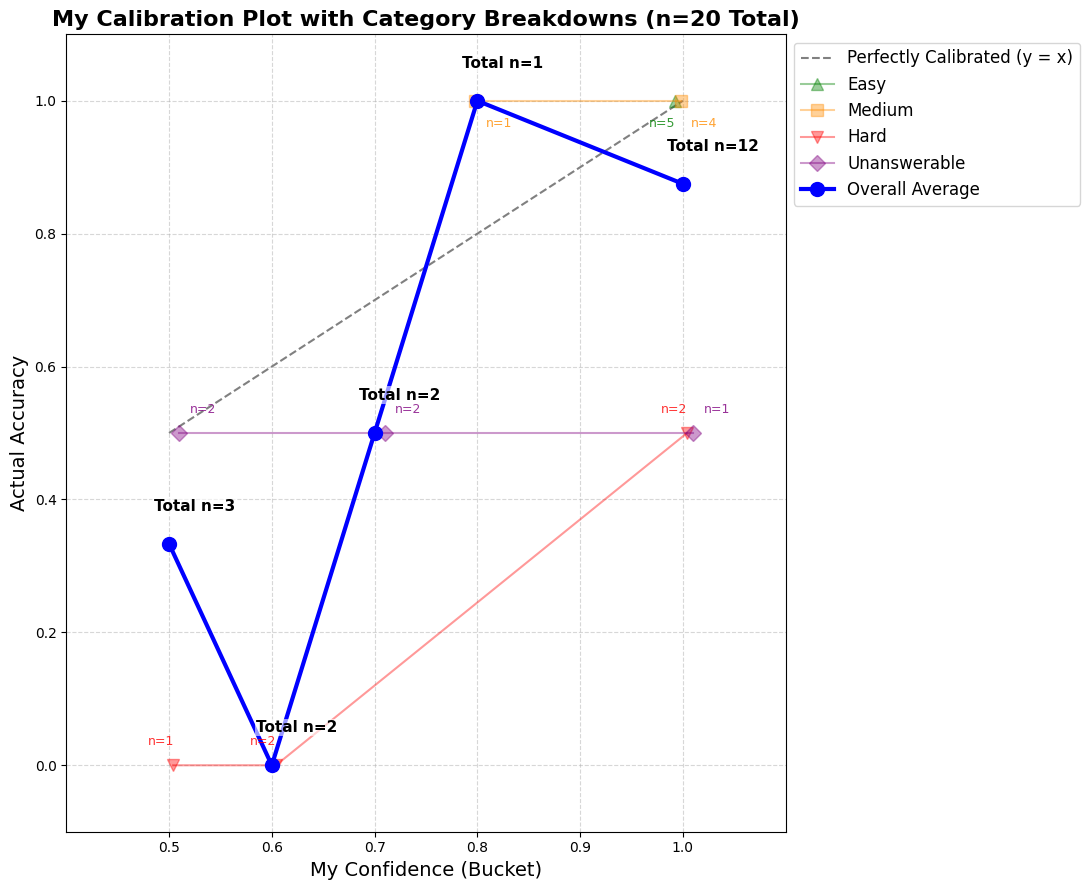

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load graded datasets
df_human = pd.read_csv('/content/drive/MyDrive/NST2062 ownself/my_calibration_data_answers.csv')

# Standardize the Difficulty column to ensure clean legend ordering
df_human['Difficulty'] = df_human['Difficulty'].str.title()

# reformat - i put 0.5 for unanswerable questions
df_human['Is_Correct'] = pd.to_numeric(df_human['Is_Correct'].replace({'Correct': 1, 'Wrong': 0, 'Unanswerable': 0.5}), errors='coerce').fillna(0)
if df_human['Confidence'].max() > 1.0:
    df_human['Confidence'] = df_human['Confidence'] / 100
df_human['Calibration_Error'] = abs(df_human['Confidence'] - df_human['Is_Correct']) # error per response

# 2. Compute metrics per Difficulty
metrics = df_human.groupby('Difficulty').agg(
    Accuracy=('Is_Correct', 'mean'),
    Average_Confidence=('Confidence', 'mean')
).reset_index()

# 3. Compute Calibration Error
metrics['Calibration_Errorr'] = abs(metrics['Average_Confidence'] - metrics['Accuracy'])
average_calibration_error = metrics['Calibration_Errorr'].mean()

print("--- CALIBRATION METRICS PER CATEGORY ---")
display(metrics)
print(f"\nTotal Average Calibration Error across all categories: {average_calibration_error:.4f}")

# EXCLUDE 'Unanswerable' from the total average calculation
valid_metrics = metrics[metrics['Difficulty'] != 'Unanswerable']
average_calibration_error_exclude_unans = valid_metrics['Calibration_Errorr'].mean()
print(f"\nTotal Average Calibration Error (excluding Unanswerable Questions): {average_calibration_error_exclude_unans:.4f}")
print("\n")

# 4. Plotting the Calibration Curve (Reliability Diagram)
bins = [0.45, 0.55, 0.65, 0.75, 0.85, 0.95, 1.05]
labels = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
df_human['Confidence_Bucket'] = pd.cut(df_human['Confidence'], bins=bins, labels=labels)

plt.figure(figsize=(11, 9))

# Plot the "Perfect Calibration" diagonal line
plt.plot([0.5, 1.0], [0.5, 1.0], linestyle='--', color='gray', label='Perfectly Calibrated (y = x)')

# --- 1. PLOT INDIVIDUAL CATEGORIES WITH TEXT JITTER ---
# Added text_x and text_y offsets to scatter the labels like a compass
category_props = {
    'Easy': {'color': 'green', 'marker': '^', 'offset': -0.008, 'text_x': -0.025, 'text_y': -0.04},
    'Medium': {'color': 'darkorange', 'marker': 's', 'offset': -0.002, 'text_x': 0.010, 'text_y': -0.04},
    'Hard': {'color': 'red', 'marker': 'v', 'offset': 0.004, 'text_x': -0.025, 'text_y': 0.03},
    'Unanswerable': {'color': 'purple', 'marker': 'D', 'offset': 0.010, 'text_x': 0.010, 'text_y': 0.03}
}

desired_order = ['Easy', 'Medium', 'Hard', 'Unanswerable']

for diff in desired_order:
    if diff in df_human['Difficulty'].values:
        df_subset = df_human[df_human['Difficulty'] == diff]
        bucket_stats_sub = df_subset.groupby('Confidence_Bucket', observed=False)['Is_Correct'].agg(['mean', 'count']).dropna()

        # Apply the horizontal line jitter
        x_values = bucket_stats_sub.index.astype(float) + category_props[diff]['offset']
        y_values = bucket_stats_sub['mean']

        # Plot the category line
        plt.plot(
            x_values,
            y_values,
            marker=category_props[diff]['marker'],
            color=category_props[diff]['color'],
            linewidth=1.5,
            markersize=8,
            alpha=0.4,
            label=f'{diff}'
        )

        # Add the 'n=' labels specifically for this category!
        for x, y, count in zip(x_values, y_values, bucket_stats_sub['count']):
            plt.text(
                x + category_props[diff]['text_x'],
                y + category_props[diff]['text_y'],
                f'n={int(count)}',
                fontsize=9,
                color=category_props[diff]['color'],
                alpha=0.8
            )

# --- 2. PLOT OVERALL AVERAGE (SOLID LINE) ---
bucket_stats_total = df_human.groupby('Confidence_Bucket', observed=False)['Is_Correct'].agg(['mean', 'count']).dropna()

x_total = bucket_stats_total.index.astype(float)
y_total = bucket_stats_total['mean']

# Plot the overall average as a thick, solid blue line
plt.plot(x_total, y_total, marker='o', color='blue', linewidth=3, markersize=10, alpha=1.0, label='Overall Average')

# Add the OVERALL 'n=' labels (styled bold and black so they stand out from the colored category counts)
for x, y, count in zip(x_total, y_total, bucket_stats_total['count']):
    plt.text(x - 0.015, y + 0.05, f'Total n={int(count)}', fontsize=11, color='black', fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)) # Adds a soft white background for readability

total_qns_plotted = int(bucket_stats_total['count'].sum())

# Formatting the chart
plt.title(f'My Calibration Plot with Category Breakdowns (n={total_qns_plotted} Total)', fontsize=16, fontweight='bold')
plt.xlabel('My Confidence (Bucket)', fontsize=14)
plt.ylabel('Actual Accuracy', fontsize=14)
plt.xlim(0.40, 1.10)
plt.ylim(-0.10, 1.10)
plt.xticks(labels)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('my_calibration_highly_detailed.png')
plt.show()

### Part C: Measure the MODEL's Calibration (15 points)

Query an LLM (use the OpenAI API, Anthropic API, or any accessible API — free tiers are fine) with all 50 questions. For each question, use the following prompt template:

```
Answer the following question. After your answer, rate your confidence
from 0% to 100% that your answer is correct. Format your response as:
Answer: [your answer]
Confidence: [X]%
```

Then:
1. **Parse** the model's answers and confidence ratings
2. **Score** each answer as correct or incorrect (you may need fuzzy matching — document your approach)
3. Compute the **model's calibration** the same way you computed yours:
   - Accuracy per difficulty category
   - Average confidence per difficulty category
   - Calibration error per category
   - Calibration plot

4. **Compare** your calibration plot to the model's calibration plot side by side.

**Key analysis questions** (answer in a markdown cell):
- Is the model overconfident, underconfident, or well-calibrated?
- Does its calibration error vary with difficulty? (Compare to humans from Lichtenstein et al. 1982)
- How does the model handle the unanswerable questions? Does it say "I don't know" or does it confabulate confidently?
- How does the model's calibration pattern differ from yours?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openai import OpenAI

OPEN_API_KEY = userdata.get('openkey')
client = OpenAI(api_key=OPEN_API_KEY)

# --- QUERY FUNCTION ---
def query_llm(question):
    prompt = f"""Answer the following question. After your answer, rate your confidence from 0% to 100% that your answer is correct. Format your response as:
Answer: [your answer]
Confidence: [X]%

Question: {question}"""

    try:
        # Temperature 0.0 forces the model to pick the highest probability tokens (best for baseline confidence)
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages = [{"role": "user", "content": prompt}],
            temperature = 0.0
            )
        return response.choices[0].message.content
    except Exception as e:
        print(f"API Error: {e}")
        return "Answer: Error\nConfidence: 0%"

# --- PARSING & FUZZY SCORING ---
def parse_and_score(row):
    # 1. Query the model
    response_text = query_llm(row['question'])

    # 2. Parse Answer and Confidence using Regex
    ans_match = re.search(r'Answer:\s*(.*?)(?=\nConfidence:|$)', response_text, re.IGNORECASE | re.DOTALL)
    conf_match = re.search(r'Confidence:\s*(\d+)', response_text, re.IGNORECASE)

    llm_answer = ans_match.group(1).strip() if ans_match else response_text.strip()
    llm_confidence = int(conf_match.group(1)) / 100.0 if conf_match else 0.5

    # 3. Fuzzy Scoring Logic
    is_correct = 0
    needs_review = False

    true_ans = str(row['answer']).lower().strip()
    llm_ans_lower = llm_answer.lower().strip()

    # Handle Unanswerable questions
    if row['difficulty'].lower() == 'unanswerable':
        # If the true answer is unanswerable, the LLM is only correct if it admits it doesn't know
        if any(phrase in llm_ans_lower for phrase in ["don't know", "cannot be answered", "no answer", "not possible", "unanswerable", "no clearly defined"]):
            is_correct = 1
            needs_review = False
    else:
        # Check for exact match first
        if true_ans == llm_ans_lower:
            is_correct = 1
            needs_review = False # Exact match, no review needed

        # Check for fuzzy match
        elif true_ans in llm_ans_lower:
            is_correct = 1
            needs_review = True # Flagged: It was marked correct, but contained extra words.

        # If it failed both, it's incorrect, but we flag it just in case the LLM was right but phrased it differently (e.g. "six" instead of "6")
        else:
            is_correct = 0
            needs_review = True

    return pd.Series([llm_answer, llm_confidence, is_correct, needs_review])

# --- RUN THE EVALUATION ---
df_llm = pd.DataFrame(questions)
df_llm[['LLM_Answer', 'LLM_Confidence', 'LLM_Is_Correct', 'Needs_Review']] = df_llm.apply(parse_and_score, axis=1)


In [ ]:
# Save file
csv_filename = 'llm_calibration_v2.csv'
df_llm.to_csv(csv_filename, index=False)

In [ ]:
# load reviewed file
df_llm_reviewed = pd.read_csv('/content/drive/MyDrive/NST2062 ownself/llm_calibration_reviewed_v2.csv')

When I was measuring my calibration, I set 0.5 as accuracy for all unanswerable questions. Since I created the questions, I knew what the answer and trick framing were. As some of the unanswerable questions were subjective, I used the 0.5 accuracy score, instead of the binary 0 or 1, so that it would not artificially inflate or deflate my calibration, since there was no right or wrong answer.

However, in measuring the LLM's calibration, I defined 'accuracy' for unanswerable questions not as providing a factual answer, but as successfully identifying the premise as unanswerable. Therefore, when the model correctly stated it did not know (and has confidence 0.5), I awarded accuracy of 0.5, resulting in perfect calibration for that specific question. For subjective questions, I gave a score of 0.5, for the same reason as above. However, for the questions with trick framing, (eg. who was the first female president of the USA?) I gave a score of 1.0 if it did identify why this question was unanswerable.

For two questions, LLM gives a confidence level less than 50%. I added a new column `adjusted confidence` so that 50% will be the baseline, signifying pure guess. This allows for fair comparison with my calibration.

In [ ]:
# --- COMPUTE LLM METRICS ---
df_llm_reviewed['Adjusted_Confidence'] = df_llm_reviewed['LLM_Confidence'].clip(lower=0.5)
df_llm_reviewed['LLM_Calibration_Error'] = abs(df_llm_reviewed['Adjusted_Confidence'] - df_llm_reviewed['LLM_Is_Correct'])

llm_metrics = df_llm_reviewed.groupby('difficulty').agg(
    LLM_Accuracy=('LLM_Is_Correct', 'mean'),
    LLM_Average_Confidence=('Adjusted_Confidence', 'mean'),
    LLM_Cal_Error=('LLM_Calibration_Error', 'mean')
).reset_index()

# Compute Average Calibration Error
llm_average_calibration_error = llm_metrics['LLM_Cal_Error'].mean()

print("--- GEMINI CALIBRATION METRICS (AFTER REVIEW) ---")
display(llm_metrics)
print(f"\nTotal Average LLM Calibration Error across all categories: {llm_average_calibration_error:.4f}")

# EXCLUDE 'Unanswerable' from the total average calculation
valid_llm_metrics = llm_metrics[llm_metrics['difficulty'] != 'Unanswerable']
average_calibration_error_exclude_unans_llm = valid_llm_metrics['LLM_Cal_Error'].mean()
print(f"\nTotal Average LLM Calibration Error (excluding Unanswerable): {average_calibration_error_exclude_unans_llm:.4f} \n")



--- GEMINI CALIBRATION METRICS (AFTER REVIEW) ---


,difficulty,LLM_Accuracy,LLM_Average_Confidence,LLM_Cal_Error
0,easy,1.000000,0.995000,0.005
1,hard,0.866667,0.926667,0.180
2,medium,0.733333,0.926667,0.240
3,unanswerable,0.650000,0.850000,0.200



Total Average LLM Calibration Error across all categories: 0.1562

Total Average LLM Calibration Error (excluding Unanswerable): 0.1562 



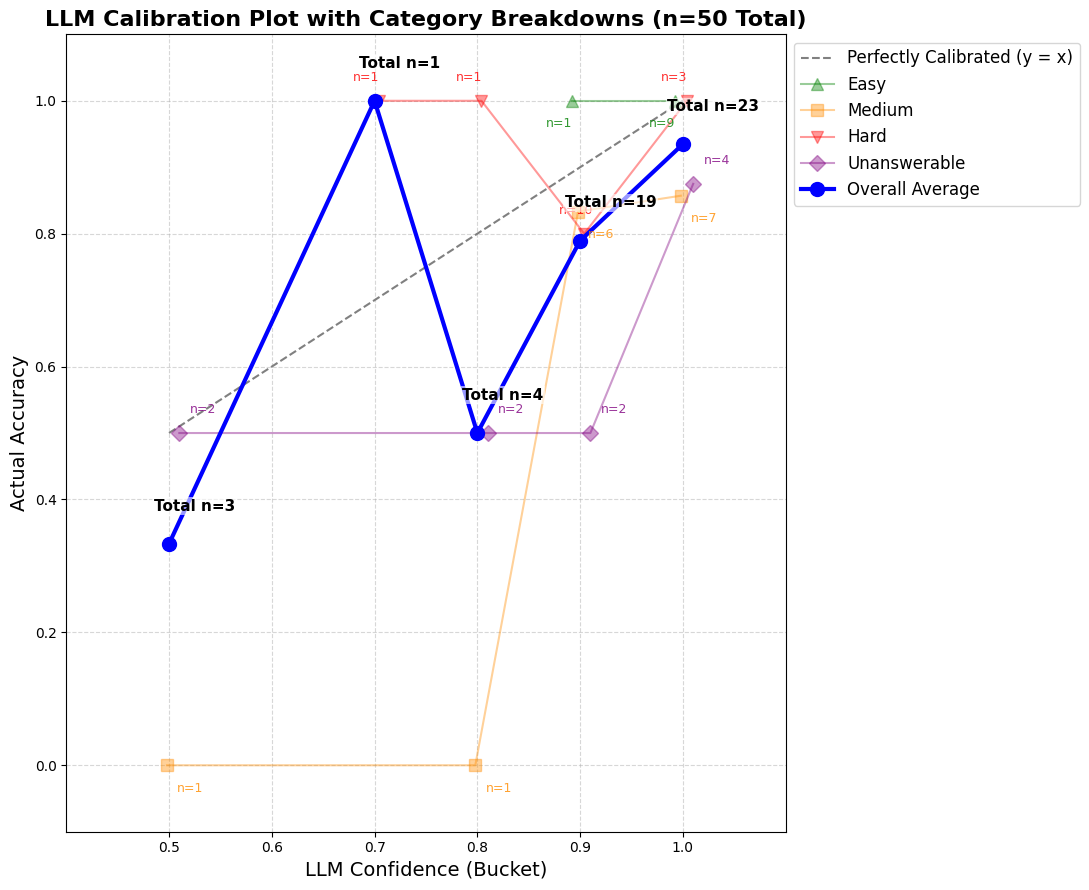

In [ ]:
# Standardize the difficulty column casing just to be safe
df_llm_reviewed['difficulty'] = df_llm_reviewed['difficulty'].astype(str).str.title()

# 4. Plotting the Calibration Curve (Reliability Diagram)
bins = [0.45, 0.55, 0.65, 0.75, 0.85, 0.95, 1.05]
labels = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
df_llm_reviewed['Confidence_Bucket'] = pd.cut(df_llm_reviewed['Adjusted_Confidence'], bins=bins, labels=labels)

plt.figure(figsize=(11, 9))

# Plot the "Perfect Calibration" diagonal line
plt.plot([0.5, 1.0], [0.5, 1.0], linestyle='--', color='gray', label='Perfectly Calibrated (y = x)')

# --- 1. PLOT INDIVIDUAL CATEGORIES WITH TEXT JITTER ---
# Added text_x and text_y offsets to scatter the labels like a compass
category_props = {
    'Easy': {'color': 'green', 'marker': '^', 'offset': -0.008, 'text_x': -0.025, 'text_y': -0.04},
    'Medium': {'color': 'darkorange', 'marker': 's', 'offset': -0.002, 'text_x': 0.010, 'text_y': -0.04},
    'Hard': {'color': 'red', 'marker': 'v', 'offset': 0.004, 'text_x': -0.025, 'text_y': 0.03},
    'Unanswerable': {'color': 'purple', 'marker': 'D', 'offset': 0.010, 'text_x': 0.010, 'text_y': 0.03}
}

desired_order = ['Easy', 'Medium', 'Hard', 'Unanswerable']

for diff in desired_order:
    if diff in df_llm_reviewed['difficulty'].values:
        df_subset = df_llm_reviewed[df_llm_reviewed['difficulty'] == diff]
        bucket_stats_sub = df_subset.groupby('Confidence_Bucket', observed=False)['LLM_Is_Correct'].agg(['mean', 'count']).dropna()

        # Apply the horizontal line jitter
        x_values = bucket_stats_sub.index.astype(float) + category_props[diff]['offset']
        y_values = bucket_stats_sub['mean']

        # Plot the category line
        plt.plot(
            x_values,
            y_values,
            marker=category_props[diff]['marker'],
            color=category_props[diff]['color'],
            linewidth=1.5,
            markersize=8,
            alpha=0.4,
            label=f'{diff}'
        )

        # Add the 'n=' labels specifically for this category
        for x, y, count in zip(x_values, y_values, bucket_stats_sub['count']):
            plt.text(
                x + category_props[diff]['text_x'],
                y + category_props[diff]['text_y'],
                f'n={int(count)}',
                fontsize=9,
                color=category_props[diff]['color'],
                alpha=0.8
            )

# --- 2. PLOT OVERALL AVERAGE (SOLID LINE) ---
bucket_stats_total = df_llm_reviewed.groupby('Confidence_Bucket', observed=False)['LLM_Is_Correct'].agg(['mean', 'count']).dropna()

x_total = bucket_stats_total.index.astype(float)
y_total = bucket_stats_total['mean']

# Plot the overall average as a thick, solid blue line
plt.plot(x_total, y_total, marker='o', color='blue', linewidth=3, markersize=10, alpha=1.0, label='Overall Average')

# Add the OVERALL 'n=' labels (styled bold and black so they stand out from the colored category counts)
for x, y, count in zip(x_total, y_total, bucket_stats_total['count']):
    plt.text(x - 0.015, y + 0.05, f'Total n={int(count)}', fontsize=11, color='black', fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)) # Adds a soft white background for readability

# Calculate total questions plotted (This was missing from your snippet!)
total_qns_plotted = int(bucket_stats_total['count'].sum())

# Formatting the chart
plt.title(f'LLM Calibration Plot with Category Breakdowns (n={total_qns_plotted} Total)', fontsize=16, fontweight='bold')
plt.xlabel('LLM Confidence (Bucket)', fontsize=14)
plt.ylabel('Actual Accuracy', fontsize=14)
plt.xlim(0.40, 1.10)
plt.ylim(-0.10, 1.10)
plt.xticks(labels)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('llm_calibration_highly_detailed.png')
plt.show()

For the question: In 2024, which country officially became the 32nd member of NATO? LLM gives an inaccurate answer and gives a confidence score of 20%. As I did not explicitly prompt the LLM to give the minimum confidence level of 50% for pure guess answers, for comparison with my calibration, I changed the confidence score to 0.50 for responses with less than 50% confidence.

When I decided to do this, Gemini feedbacked that I should evaluate the machine on its own term, and not alter the model's actual calibration curve to fit a human psychological framework. However, I decided to ignore this feedback and treated my method as a way to 'normalise' the scores. I also tested and prompted the LLM to give 0.50 as the minimum, to which it gave 0.50 as well, so I think that supports my hypothesis.

/tmp/ipykernel_2475/3069942623.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_human['Is_Correct'] = pd.to_numeric(df_human['Is_Correct'].replace({'Correct': 1, 'Wrong': 0, 'Unanswerable': 0.5}), errors='coerce').fillna(0)


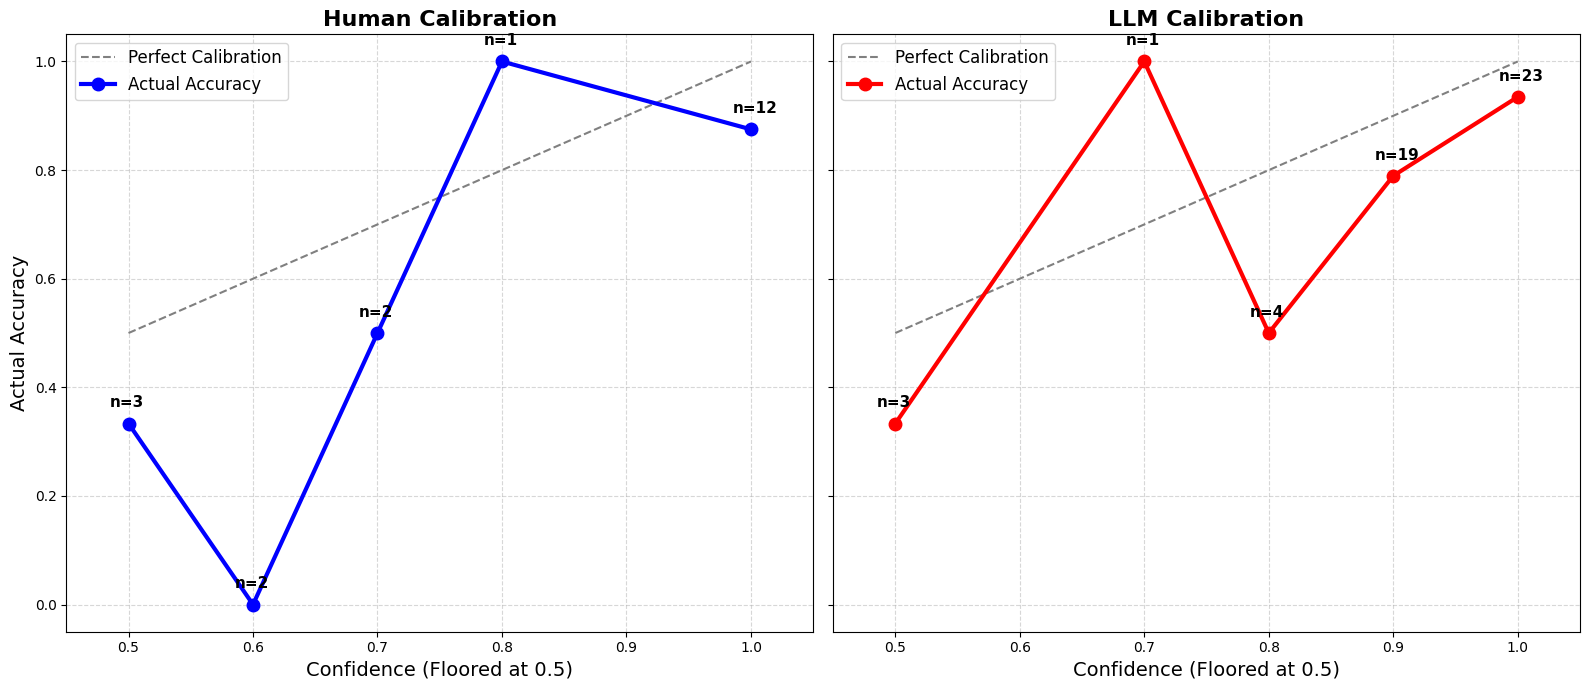

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 6. SIDE-BY-SIDE CALIBRATION PLOT ---

# 1. Load Human Dataset
df_human = pd.read_csv('/content/drive/MyDrive/NST2062 ownself/my_calibration_data_answers.csv')
df_human['Is_Correct'] = pd.to_numeric(df_human['Is_Correct'].replace({'Correct': 1, 'Wrong': 0, 'Unanswerable': 0.5}), errors='coerce').fillna(0)
if df_human['Confidence'].max() > 1.0:
    df_human['Confidence'] = df_human['Confidence'] / 100

df_human['Adjusted_Confidence'] = df_human['Confidence'].clip(lower=0.5)
df_llm_reviewed['Adjusted_Confidence'] = df_llm_reviewed['LLM_Confidence'].clip(lower=0.5)

# 2. Define Bins and Buckets
bins = [0.45, 0.55, 0.65, 0.75, 0.85, 0.95, 1.05]
labels = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Apply buckets to both datasets
df_human['Human_Bucket'] = pd.cut(df_human['Adjusted_Confidence'], bins=bins, labels=labels)
df_llm_reviewed['LLM_Bucket'] = pd.cut(df_llm_reviewed['Adjusted_Confidence'], bins=bins, labels=labels)

# 3. Plotting Setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Function to plot a specific axis
def plot_calibration(ax, data, bucket_col, correct_col, title, color):
    ax.plot([0.5, 1.0], [0.5, 1.0], linestyle='--', color='gray', label='Perfect Calibration')

    # Now it groups whatever specific 'data' dataframe you pass to it
    stats = data.groupby(bucket_col, observed=False)[correct_col].agg(['mean', 'count']).dropna()
    x_vals = stats.index.astype(float)
    y_vals = stats['mean']

    ax.plot(x_vals, y_vals, marker='o', color=color, linewidth=3, markersize=9, label='Actual Accuracy')

    for x, y, count in zip(x_vals, y_vals, stats['count']):
        ax.text(x - 0.015, y + 0.03, f'n={int(count)}', fontsize=11, fontweight='bold')

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Confidence (Floored at 0.5)', fontsize=14)
    ax.set_xlim(0.45, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=12)

# 4. Plot Human on the Left, LLM on the Right
# Pass df_human and df_llm_reviewed into the function
plot_calibration(ax1, df_human, 'Human_Bucket', 'Is_Correct', 'Human Calibration', 'blue')
plot_calibration(ax2, df_llm_reviewed, 'LLM_Bucket', 'LLM_Is_Correct', 'LLM Calibration', 'red')

ax1.set_ylabel('Actual Accuracy', fontsize=14)
plt.tight_layout()
plt.savefig('side_by_side_calibration_final.png')
plt.show()

#### Analysis Questions

**Is the model overconfident, underconfident, or well-calibrated?**

The model is overconfident as the confidence level is mostly higher than accuracy level.

The only time it was underconfident was when the accuracy score of 1.0 is at 70% confidence level. However, this was only one out of 50 questions, so there is insufficient data points to validate the underconfidence.

Notably, most of the questions that the LLM got wrong were because the questions had to do with current events. For the question on `In 2024, which country officially became the 32nd member of NATO?`, it gave the answer `Australia` with a 20% confidence level. For `What is the farthest known star from Earth?`, the LLM answers `Icarus` with 90% confidence, and not the star `Earendel` discovered in 2022. Finally, for the question on `which is the highest grossing film in 2025`, LLM says its impossible to predict the future. This makes me think that this LLM is not trained on recent information, so it makes this mistake.

**Does its calibration error vary with difficulty? (Compare to humans from Lichtenstein et al. 1982)**

No, from my runs, calibration error does not increase with difficulty (ignoring the unanswerable questions). This was an interesting finding because it was in contrast to the lecture that LLM's confidence is uniform, since it was never trained to track truth. If LLM's confidence was uniform, the calibration error should be increasing with difficulty. Perhaps LLM knows some questions are difficult and hence reduces its confidence level on accuracy.

Closer analysis on the specific questions with low confidence level for medium questions reveal that these questions were related to the current events questions mentioned earlier (ie. 2024 NATO question and highest grossing film in 2025). So LLM is ablee to identify its own limitations in predicting the 'future' from the data it was trained on, hence it is well-calibrated in stating it is uncertain about future events.

Reflecting on the kind of questions I asked, I realised that maybe I should have added more recent "2025 questions" in the hard section too, to test if this is indeed true.

**How does the model handle the unanswerable questions? Does it say "I don't know" or does it confabulate confidently?**

For two of the unanswerable questions, it realistically gives the lower baseline confidence (0.50) and says it does not know. For example, for the question on `when will the iran war end?`, it answers with, `"It is impossible to predict with certainty when the Iran War will end as it depends on various factors and developments in the region."` This shows the model's well-calibration in predicting future events, that it does not know. Additionally, for the question on `What happens after death?`, the LLM also gives a low confidence of 50% and says there are various beliefs and theories on afterlife.

For the trick framing questions (eg. `Who was the first female president of the United States?` and `How may animals of each species did Moses bring into the ark?`), the LLM is able to identify the trick framing and answer confidently and correctly.

However, for the other subjective questions, such as `Is water wet?`, it answers very confidently. It seems like the LLM suffers from a blind spot and is unaware of the debates on such questions that make it unanswerable, or that it could have been trained on millions of assertive internet arguments on that `water is not wet but can make other things wet`. Hence, it pattern matches the assertiveness and confidently (~0.95) confabulates the answer, missing the context that makes it an unresolvable debate.

**How does the model's calibration pattern differ from yours?**

It is pretty similar. For easy questions, both are highly confident and accurate. For medium and hard questions, accuracy generally increases with confidence and both calibration patterns reveal overconfidence. However, the smaller dataset that I have also limits the comparison and may not give a complete comparison on calibration. The kind of questions I asked could have also limited the robustness of this calibration pattern.


### Part D: Can You Improve the Model's Calibration? (10 points)

Try at least **two** prompt engineering interventions to improve the model's calibration. Ideas:
- Ask it to "think step by step before rating confidence"
- Ask it to "list reasons it might be wrong before answering"
- Ask it to "rate confidence on a scale of 1-10 instead of percentage"
- Provide a few-shot example of well-calibrated answers (including "I'm not sure")
- Ask in a different persona ("You are a careful scientist who hates being wrong...")

For each intervention:
1. Re-run the 50 questions with the new prompt
2. Compute calibration again
3. Compare to the baseline

**Report**: Which intervention helped most? Which didn't help? Why do you think that is (connect to what you know about RLHF and reward signals from Lecture 3)?

In [ ]:
import pandas as pd
import re
import time
from openai import OpenAI

# Intialise client
OPEN_API_KEY = userdata.get('openkey')
client = OpenAI(api_key=OPEN_API_KEY)

# Load original 50 questions
questions_list = [item['question'] for item in questions]

# Reusable querying function
def run_single_intervention(intervention_name, prompt_template, questions):
    results = []
    print(f"--- Starting: {intervention_name} ---")

    for q in questions:
        prompt = prompt_template.format(question=q)
        try:
            response = client.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0
            )
            text = response.choices[0].message.content

            # Extract Answer and Confidence
            ans_match = re.search(r'Answer:\s*(.*)', text, re.IGNORECASE)
            conf_match = re.search(r'Confidence:\s*(\d+)', text, re.IGNORECASE)

            answer = ans_match.group(1).strip() if ans_match else "Parse Error"
            confidence = int(conf_match.group(1)) / 100 if conf_match else 0.0

            results.append({
                "Question": q,
                "Intervention": intervention_name,
                "Raw_Output": text,
                "LLM_Answer": answer,
                "LLM_Confidence": confidence
            })
        except Exception as e:
            print(f"Error on question '{q}': {e}")

        time.sleep(0.5) # Rate limit protection

    df_result = pd.DataFrame(results)
    filename = f'/content/drive/MyDrive/NST2062 ownself/{intervention_name}_results.csv'
    df_result.to_csv(filename, index=False)
    print(f"[SUCCESS] Saved to {filename}\n")
    return df_result


#### Intervention 1: List two reasons why it might be wrong

In [ ]:
prompt_reasons = """Before answering, list at least two reasons why your initial instinct might be wrong. Then, provide your final answer and rate your confidence from 0% to 100%. Format exactly as:
Reasons: [your reasons]
Answer: [your answer]
Confidence: [X]%

Question: {question}"""

df_reasons = run_single_intervention("Intervention_1_Reasons", prompt_reasons, questions_list)

--- Starting: Intervention_1_Reasons ---
[SUCCESS] Saved to /content/drive/MyDrive/NST2062 ownself/Intervention_1_Reasons_results.csv



#### Intervention 2: Think Step by Step before answering

This is also chain-of-thought processing

In [ ]:
prompt_cot = """Think step-by-step to deduce the correct answer. Write out your reasoning. Then, provide your final answer and rate your confidence from 0% to 100%. Format exactly as:
Reasoning: [your step-by-step thoughts]
Answer: [your answer]
Confidence: [X]%

Question: {question}"""

df_cot = run_single_intervention("Intervention_2_StepByStep", prompt_cot, questions_list)

--- Starting: Intervention_2_StepByStep ---
[SUCCESS] Saved to /content/drive/MyDrive/NST2062 ownself/Intervention_2_StepByStep_results.csv



#### Intervention 3: Take on the persona of a careful teacher who cannot afford to teach students misinformation

In [ ]:
prompt_persona = """You are a careful teacher who hates being wrong and imparting wrong information to students. Your students tend to take your word for it, but they will do their research to fact-check you if you give a low confidence level score. So it is okay to rate yourself as less confident.
Answer the following question, then rate your confidence from 0% to 100%. Format exactly as:
Answer: [your answer]
Confidence: [X]%

Question: {question}"""

df_persona = run_single_intervention("Intervention_3_Persona", prompt_persona, questions_list)

--- Starting: Intervention_3_Persona ---
[SUCCESS] Saved to /content/drive/MyDrive/NST2062 ownself/Intervention_3_Persona_results.csv



#### Comparing analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Compile the three dataframes
df_compiled = pd.concat([df_reasons, df_cot, df_persona], ignore_index=True)

# 2. Add an empty column for manual grading
df_compiled['LLM_Is_Correct'] = ""

# 3. Save to a single CSV
csv_filename = "compiled_interventions_to_grade.csv"
df_compiled.to_csv(csv_filename, index=False)

print(f"[SUCCESS] Combined dataset saved to '{csv_filename}'.")
print(f"Total rows to grade: {len(df_compiled)}")

[SUCCESS] Combined dataset saved to 'compiled_interventions_to_grade.csv'.
Total rows to grade: 150


Some of the outputs have confidence level less than 50%. For these lower than 50% confidence levels, I added a new column to convert these to 50% (pure guess).

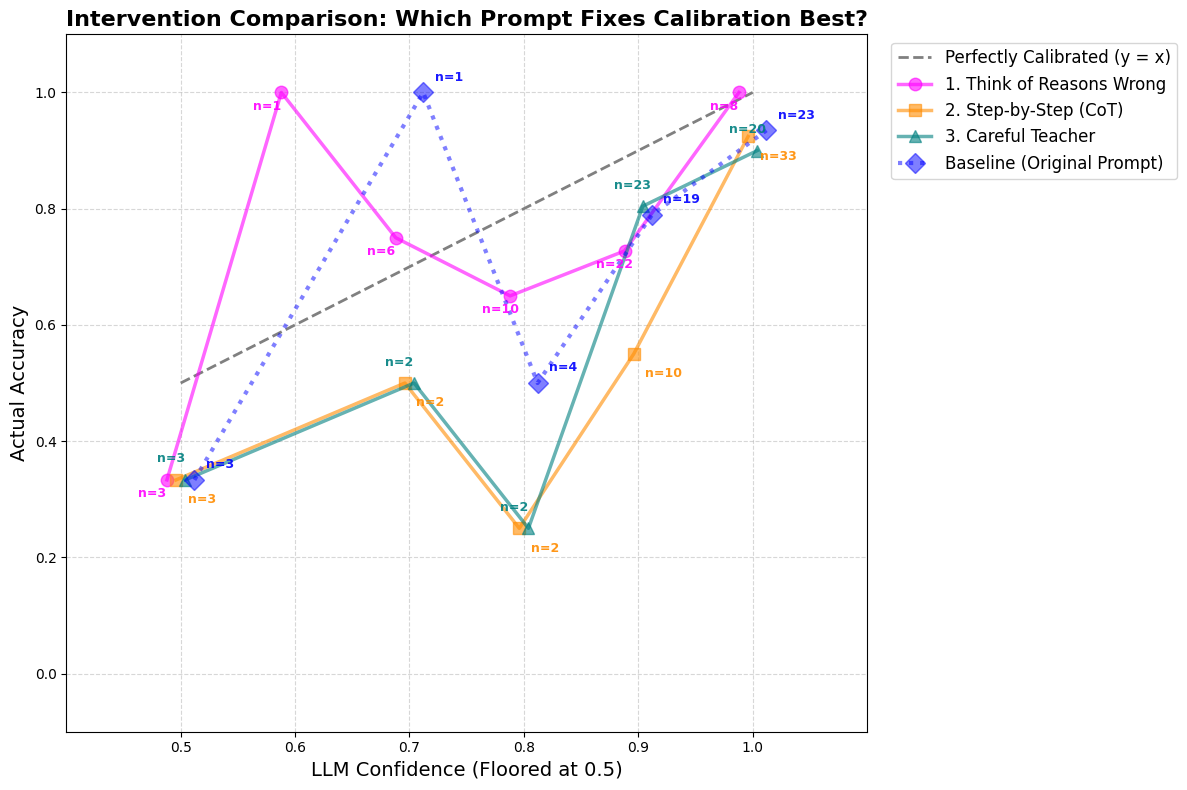

In [ ]:
# 1. Load the manually graded file
df_graded = pd.read_csv('/content/drive/MyDrive/NST2062 ownself/compiled_interventions_graded.csv')

# Ensure the grading column is read as numbers
df_graded['LLM_Is_Correct'] = pd.to_numeric(df_graded['LLM_Is_Correct'], errors='coerce')

# Create a new column where any confidence less than 0.5 is pulled up to exactly 0.5
df_graded['Adjusted_Confidence'] = df_graded['LLM_Confidence'].clip(lower=0.5)

# 2. Set up the confidence buckets
bins = [0.45, 0.55, 0.65, 0.75, 0.85, 0.95, 1.05]
labels = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
df_graded['Confidence_Bucket'] = pd.cut(df_graded['Adjusted_Confidence'], bins=bins, labels=labels)

# Set up the plot
plt.figure(figsize=(12, 8))

# Plot Perfect Calibration
plt.plot([0.5, 1.0], [0.5, 1.0], linestyle='--', color='gray', linewidth=2, label='Perfectly Calibrated (y = x)')

# 3. Define styles for each intervention to make them visually distinct
intervention_styles = {
    "Intervention_1_Reasons": {
        "color": "magenta", "marker": "o", "label": "1. Think of Reasons Wrong",
        "offset": -0.012, "text_x": -0.025, "text_y": -0.03
    },
    "Intervention_2_StepByStep": {
        "color": "darkorange", "marker": "s", "label": "2. Step-by-Step (CoT)",
        "offset": -0.004, "text_x": 0.010, "text_y": -0.04
    },
    "Intervention_3_Persona": {
        "color": "teal", "marker": "^", "label": "3. Careful Teacher",
        "offset": 0.004, "text_x": -0.025, "text_y": 0.03
    }
}

for intervention_name, style in intervention_styles.items():
    df_sub = df_graded[df_graded['Intervention'] == intervention_name]

    if not df_sub.empty:
        stats = df_sub.groupby('Confidence_Bucket', observed=False)['LLM_Is_Correct'].agg(['mean', 'count']).dropna()

        # Apply the horizontal line jitter
        x_vals = stats.index.astype(float) + style['offset']
        y_vals = stats['mean']

        plt.plot(
            x_vals, y_vals,
            marker=style['marker'],
            color=style['color'],
            linewidth=2.5,
            markersize=9,
            alpha=0.6, # Translucency so overlapping lines can be seen
            label=style['label']
        )

        # Add the 'n=' labels for this intervention
        for x, y, count in zip(x_vals, y_vals, stats['count']):
            plt.text(
                x + style['text_x'],
                y + style['text_y'],
                f'n={int(count)}',
                fontsize=9,
                color=style['color'],
                alpha=0.9,
                fontweight='bold'
            )

# 5. Add Baseline (Using Original LLM Data) with Jitter
if 'df_llm_reviewed' in globals():
    df_llm_reviewed['Adjusted_Confidence'] = df_llm_reviewed['LLM_Confidence'].clip(lower=0.5)
    df_llm_reviewed['Confidence_Bucket'] = pd.cut(df_llm_reviewed['Adjusted_Confidence'], bins=bins, labels=labels)

    # Notice I added 'count' here so we can print the n-labels for the baseline too!
    base_stats = df_llm_reviewed.groupby('Confidence_Bucket', observed=False)['LLM_Is_Correct'].agg(['mean', 'count']).dropna()

    base_offset = 0.012
    x_base = base_stats.index.astype(float) + base_offset
    y_base = base_stats['mean']

    plt.plot(
        x_base, y_base,
        marker='D', color='blue', linewidth=3, markersize=10, alpha=0.5,
        linestyle=':', label='Baseline (Original Prompt)'
    )

    # Add the 'n=' labels for the baseline
    for x, y, count in zip(x_base, y_base, base_stats['count']):
        plt.text(
            x + 0.010, # Push text slightly right
            y + 0.02,  # Push text slightly up
            f'n={int(count)}',
            fontsize=9,
            color='blue',
            alpha=0.9,
            fontweight='bold'
        )

# 6. Formatting the Chart
plt.title('Intervention Comparison: Which Prompt Fixes Calibration Best?', fontsize=16, fontweight='bold')
plt.xlabel('LLM Confidence (Floored at 0.5)', fontsize=14)
plt.ylabel('Actual Accuracy', fontsize=14)
plt.xlim(0.40, 1.10) # Widened slightly to fit the jittered text
plt.ylim(-0.10, 1.10)
plt.xticks(labels)
plt.grid(True, linestyle='--', alpha=0.5)

# Place the legend cleanly outside the plot area
plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig('interventions_calibration_comparison_adjusted.png')
plt.show()

#### Report

**Which intervention helped most? Which didn't help? Why do you think that is (connect to what you know about RLHF and reward signals from Lecture 3)?**

Overall, the plot clearly shows that prompting the LLM to `list reasons it might be wrong` is the most effective intervention. Its calibration curve was pulled significantly closer to the perfect calibration line. Conversely, both the chain-of-thought (step by step) and the careful teacher persona interventions failed to significantly improve calibration, and worsens the baseline llm calibration to be more overconfident.

For the teacher persona intervention, even though the prompt explicitly stated that it is "okay to rate yourself as less confident," the model remained highly overconfident. This was surprising to me as I thought the model would intentionally lower confidence. This could be due to RLHF training, where the model's reward signals heavily penalise saying "I don't know", which human raters often score as unhelpful. Instead, the model's reward signals reward confident and authoritative-sounding text. A single system prompt asking it to be careful is not a strong enough signal to override the gradient updates that mapped helpfulness to high confidence in the model's latent space.

Chain of thought (or the step by step) processing reinforced the model's overconfidence when it broke down questions based on flawed inital premises. For example, when answering the question `which country has the most islands in the world?`, LLM reasoned that the country would likely be a large achipelago or have a vast coastline, and hence incorrectly concluded Indonesia instead of Sweden. I think this means that the model's final confidence score is not evaluating objective reality. It is evaluating the internal consistency of its own generated text, whether it flows from the previous step to the next step. Since LLMs are autoregressive, once it generates the token "archipelago", the probability distribution narrows toward "Indonesia". By the time it reaches the end of the prompt to assign a confidence score, it is 95% confident because its answer aligns with its own flawed reasoning steps.

The counter-factual prompt to `list reasons why you might be wrong` was the only successful intervention because it short-circuited the model's RLHF induced sycophancy. Standard prompting allows the model to immediately predict the highly-reward confident tokens. By forcing the model to explicitly generate text arguing against its initial instinct, it forces the model to traverse to alternative semantic clusters. When the model finally predicts the confidence integer, its context window now contains contradictory information, which then lowers the probability distribution of the instincitive answer generated and recalibrates the confidence level of the LLM. This thus gives a much better calibration.

### Bonus: Token-Level Probabilities (10 bonus points)

If you're using an API that exposes log-probabilities (e.g., OpenAI with `logprobs=True`):
1. Extract the **token-level probabilities** for the model's answers
2. Compare the model's **stated** confidence (from the text) to its **actual** token probabilities
3. Are they correlated? Is the model's internal uncertainty (log-probs) better calibrated than its stated confidence?

This gets at a deep question from Lecture 2 (Representation): the model may have an internal representation of uncertainty that differs from what it expresses in text. The expressed confidence was shaped by RLHF; the log-probs were shaped by pre-training.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import time
from openai import OpenAI

# Load questions
questions_list = questions_list

prompt_template = """Answer the following question. After your answer, rate your confidence from 50% (pure guess) to 100%. Format exactly as:
Answer: [your answer]
Confidence: [X]%

Question: {question}"""

results = []
print("--- Extracting Internal Log-Probabilities ---")

for q in questions_list:
    prompt = prompt_template.format(question=q)
    try:
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
            logprobs=True # THE CRITICAL NEW PARAMETER
        )

        # 1. Parse the Stated Text
        text = response.choices[0].message.content
        ans_match = re.search(r'Answer:\s*(.*)', text, re.IGNORECASE)
        conf_match = re.search(r'Confidence:\s*(\d+)', text, re.IGNORECASE)

        stated_answer = ans_match.group(1).strip() if ans_match else "Parse Error"
        stated_confidence = int(conf_match.group(1)) / 100 if conf_match else 0.0

        # 2. Extract and Calculate Internal Probability
        # logprobs are returned as negative numbers (e.g., -0.105).
        # We take the average logprob of the generated tokens, then use np.exp() to convert it back to a standard percentage (0.0 to 1.0)
        logprobs_data = response.choices[0].logprobs.content
        token_logprobs = [token.logprob for token in logprobs_data]
        mean_logprob = np.mean(token_logprobs)
        internal_probability = np.exp(mean_logprob)

        results.append({
            "Question": q,
            "LLM_Answer": stated_answer,
            "Stated_Confidence": stated_confidence,
            "Internal_Probability": internal_probability
        })

    except Exception as e:
        print(f"Error on question '{q}': {e}")

    time.sleep(0.5)

# Convert to DataFrame
df_logprobs = pd.DataFrame(results)

# Save so you can grade the LLM_Answer column (1 for correct, 0 for wrong)
df_logprobs.to_csv('logprobs_results_to_grade.csv', index=False)

--- Extracting Internal Log-Probabilities ---


Pearson Correlation between Stated Confidence and Internal Probability: 0.5121
Stated Confidence Calibration Error: 0.2220
Internal Log-Prob Calibration Error: 0.2262


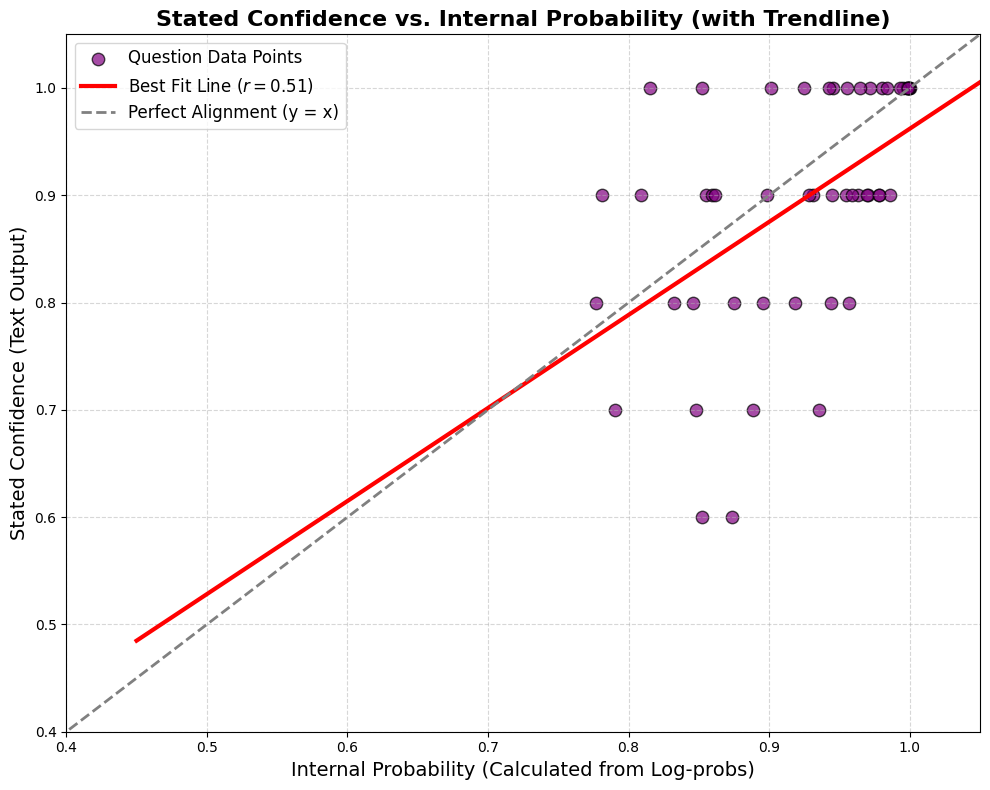

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the graded logprobs data
df_graded_logprobs = pd.read_csv('/content/drive/MyDrive/NST2062 ownself/logprobs_results_graded.csv')
df_graded_logprobs['LLM_Is_Correct'] = pd.to_numeric(df_graded_logprobs['LLM_Is_Correct'], errors='coerce')

# --- 1. CALCULATE CORRELATION ---
correlation = df_graded_logprobs['Stated_Confidence'].corr(df_graded_logprobs['Internal_Probability'])
print(f"Pearson Correlation between Stated Confidence and Internal Probability: {correlation:.4f}")

# --- 2. CALCULATE CALIBRATION ERRORS ---
# Assuming floor of 0.5 for a fair test
df_graded_logprobs['Adj_Stated_Conf'] = df_graded_logprobs['Stated_Confidence'].clip(lower=0.5)
df_graded_logprobs['Adj_Internal_Prob'] = df_graded_logprobs['Internal_Probability'].clip(lower=0.5)

stated_cal_error = abs(df_graded_logprobs['Adj_Stated_Conf'] - df_graded_logprobs['LLM_Is_Correct']).mean()
internal_cal_error = abs(df_graded_logprobs['Adj_Internal_Prob'] - df_graded_logprobs['LLM_Is_Correct']).mean()

print(f"Stated Confidence Calibration Error: {stated_cal_error:.4f}")
print(f"Internal Log-Prob Calibration Error: {internal_cal_error:.4f}")

# --- 3. SCATTER PLOT WITH BEST FIT LINE ---
plt.figure(figsize=(10, 8))

# Define X and Y for plotting
x = df_graded_logprobs['Internal_Probability']
y = df_graded_logprobs['Stated_Confidence']

# Plot the raw data points
plt.scatter(x, y, color='purple', alpha=0.7, s=80, edgecolor='black', label='Question Data Points')

# Calculate the Line of Best Fit (Linear Regression: y = mx + b)
m, b = np.polyfit(x, y, 1)

# Generate points for the line extending slightly beyond the data points
x_line = np.linspace(0.45, 1.05, 100)
y_line = m * x_line + b

# Plot the Best Fit Line
plt.plot(x_line, y_line, color='red', linewidth=3, linestyle='-', label=f'Best Fit Line ($r={correlation:.2f}$)')

# Add a y=x reference line (Perfect Alignment)
plt.plot([0, 1.05], [0, 1.05], linestyle='--', color='gray', linewidth=2, label='Perfect Alignment (y = x)')

# Formatting the Chart
plt.title('Stated Confidence vs. Internal Probability (with Trendline)', fontsize=16, fontweight='bold')
plt.xlabel('Internal Probability (Calculated from Log-probs)', fontsize=14)
plt.ylabel('Stated Confidence (Text Output)', fontsize=14)

# Set axes to match the floored 0.5 behavior if desired (or keep 0 to 1.05 to see the whole picture)
plt.xlim(0.40, 1.05)
plt.ylim(0.40, 1.05)

plt.grid(True, linestyle='--', alpha=0.5)

# Place the legend in a clear spot
plt.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.savefig('logprobs_scatter_with_bestfit.png')
plt.show()

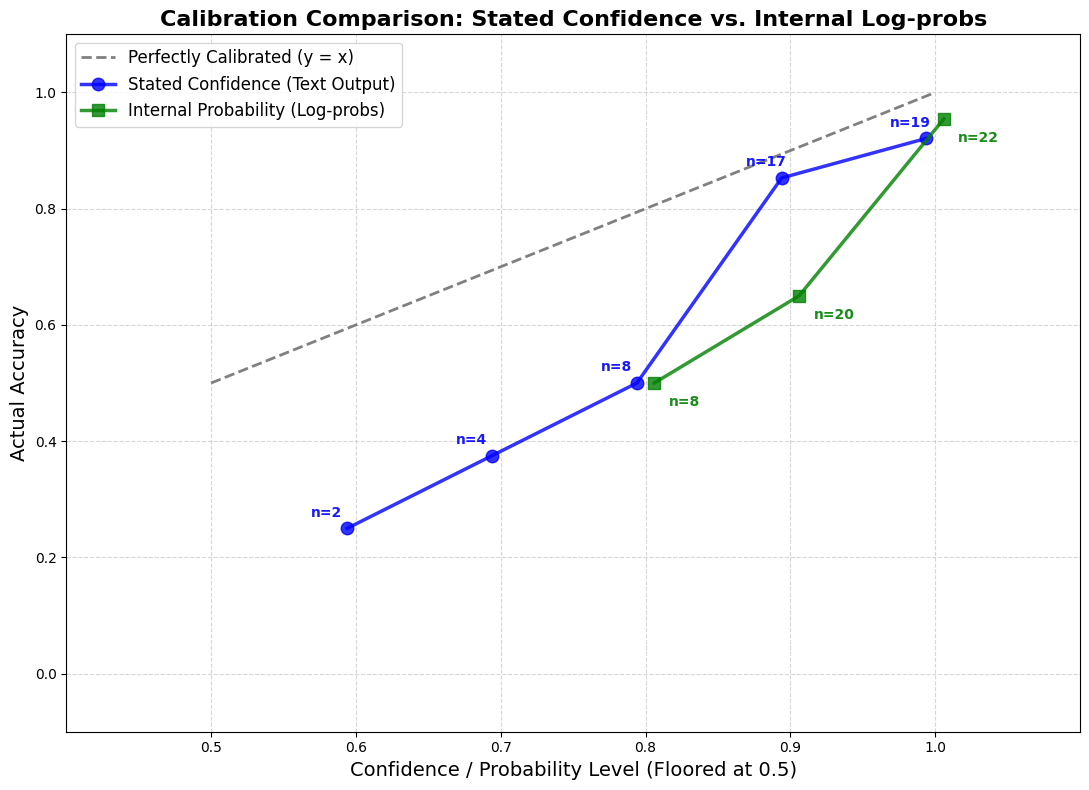

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the graded data
df_graded_logprobs = pd.read_csv('/content/drive/MyDrive/NST2062 ownself/logprobs_results_graded.csv')

# 2. Floor both confidence metrics at 0.5
df_graded_logprobs['Adj_Stated_Conf'] = df_graded_logprobs['Stated_Confidence'].clip(lower=0.5)
df_graded_logprobs['Adj_Internal_Prob'] = df_graded_logprobs['Internal_Probability'].clip(lower=0.5)

# 3. Set up the confidence buckets
bins = [0.45, 0.55, 0.65, 0.75, 0.85, 0.95, 1.05]
labels = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

df_graded_logprobs['Bucket_Stated'] = pd.cut(df_graded_logprobs['Adj_Stated_Conf'], bins=bins, labels=labels)
df_graded_logprobs['Bucket_Internal'] = pd.cut(df_graded_logprobs['Adj_Internal_Prob'], bins=bins, labels=labels)

# 4. Set up the plot
plt.figure(figsize=(11, 8))

# Plot Perfect Calibration
plt.plot([0.5, 1.0], [0.5, 1.0], linestyle='--', color='gray', linewidth=2, label='Perfectly Calibrated (y = x)')

# --- 5A. Plot Stated Confidence (RLHF Output) ---
stats_stated = df_graded_logprobs.groupby('Bucket_Stated', observed=False)['LLM_Is_Correct'].agg(['mean', 'count']).dropna()
x_stated = stats_stated.index.astype(float) - 0.006 # Jitter slightly left
y_stated = stats_stated['mean']

plt.plot(
    x_stated, y_stated,
    marker='o', color='blue', linewidth=2.5, markersize=9, alpha=0.8,
    label='Stated Confidence (Text Output)'
)

# Add n= labels for Stated
for x, y, count in zip(x_stated, y_stated, stats_stated['count']):
    plt.text(x - 0.025, y + 0.02, f'n={int(count)}', color='blue', fontsize=10, fontweight='bold', alpha=0.9)

# --- 5B. Plot Internal Probability (Pre-trained Log-probs) ---
stats_internal = df_graded_logprobs.groupby('Bucket_Internal', observed=False)['LLM_Is_Correct'].agg(['mean', 'count']).dropna()
x_internal = stats_internal.index.astype(float) + 0.006 # Jitter slightly right
y_internal = stats_internal['mean']

plt.plot(
    x_internal, y_internal,
    marker='s', color='green', linewidth=2.5, markersize=9, alpha=0.8,
    label='Internal Probability (Log-probs)'
)

# Add n= labels for Internal
for x, y, count in zip(x_internal, y_internal, stats_internal['count']):
    plt.text(x + 0.010, y - 0.04, f'n={int(count)}', color='green', fontsize=10, fontweight='bold', alpha=0.9)

# 6. Formatting the Chart
plt.title('Calibration Comparison: Stated Confidence vs. Internal Log-probs', fontsize=16, fontweight='bold')
plt.xlabel('Confidence / Probability Level (Floored at 0.5)', fontsize=14)
plt.ylabel('Actual Accuracy', fontsize=14)
plt.xlim(0.40, 1.10)
plt.ylim(-0.10, 1.10)
plt.xticks(labels)
plt.grid(True, linestyle='--', alpha=0.5)

# Place legend
plt.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.savefig('calibration_stated_vs_internal_curve.png')
plt.show()

#### Analysis

The data reveals a positive moderate correlation (Pearson r = 0.5121) between the model's explicitly stated confidence and its internal token-level probabilities. The second plot shows that between internal probability and confidence level, both are overconfident. However, the internal probability is much higher than the overconfidence stated. The internal probability line only starts at 0.8, but its actual accuracy was 0.5 (esp for unanswerable questions). This means its foundational next-token prediction was highly confident even when giving wrong answers. This could be due to the trick framing or subjective unanswerable questions, which caused strong but incorrect word associations.

Hence, the model has an internal representation of uncertainty that differs from what is expressed in text. The expressed confidence was shaped by RLHF and the log-probs were shaped by pre-training. From the lecture, I learnt that token probabilities express uncertainty, but not calibrated to truth, this data seems to agree with the lecture.

[Honestly I don't know how to make sense of this so the next paragraph onwards is gemini-ed]

The scatter plot visually demonstrates a striking dissociation between these two metrics. Rather than systematically clustering above or below the perfect alignment line (y=x), the data is widely dispersed, indicating that RLHF pulls the model's stated confidence to extreme ends of the spectrum regardless of its internal mathematical state.

This dissociation manifests in two distinct behaviors:

1. Artificial Hedging (Points below the line): There is a dense horizontal cluster of points where the stated confidence is 0.50, yet the internal probability ranges from 0.80 to nearly 1.0. This suggests that for certain prompts—likely the unanswerable or trick questions—RLHF safety guardrails successfully intervened. The model was trained to express uncertainty or abstain (resulting in a low stated confidence), even though its foundational next-token prediction engine remained highly confident in the sequence of words it was generating.

2. Exaggerated Certainty (Points above the line): Conversely, there are multiple instances where the model's internal probability was relatively low (e.g., 0.50 - 0.70), but it output a stated confidence of 0.90 or 1.0. This represents RLHF-induced sycophancy, where the reward model heavily incentivized authoritative text generation, causing the model to mask its true epistemic doubt.

Looking at the calibration curves, it is clear that neither representation is perfectly calibrated, as both lines sit largely below the actual accuracy baseline. The internal log-probabilities (green line) are highly compressed between 0.80 and 1.0, failing to recognize when it is objectively wrong. Meanwhile, the stated confidence (blue line) is artificially spread out by behavioral conditioning. Ultimately, the model possesses an internal representation of uncertainty that differs drastically from its text output, proving that RLHF disrupts the inherent calibration of the pre-trained model to satisfy human preference patterns.

ahhh that's cools.






### 🪞 Metacognitive Reflection — Problem 1 (graded, 5 points included above)

Write 200–400 words answering these questions. **This must be in your own voice — not generated by an LLM.**

1. Were you surprised by your own calibration results? Where were you most overconfident?
2. Were you surprised by the model's calibration? How did it compare to your expectations?
3. What did you learn about the relationship between confidence and accuracy — in yourself and in the model?
4. How did you use LLMs during this problem? What did you prompt for, what did you have to fix, and what did the LLM get wrong?
5. Connect your findings to one concept from the course (e.g., Goodhart's Law, prediction error, the Bayesian brain). How does your data illustrate or challenge that concept?

I initially thought that creating the questions would give me an unfair advantage, because I would remember the answers and score well in the questions. But I was surprised to find myself overconfident and wrong, frequently on the hard technical questions. I think it was precisely my creator bias that led to false memories of the answers formed and overconfidence. Hence, as the difficulty of questions increases, my calibration error increases, reflecting Lichtenstein et al. (1982) theory on human’s overconfidence effect to incorrect answers on challenging tasks. My overall calibration error was 0.1967 (excluding unanswerable questions). I thought this also reflects the lecture on overconfidence that "Experts are less calibrated than novices (Tetlock, 2005)". Since I created the questions, I deemed myself as the expert, and hence I had a higher calibration error and was overconfident.

To avoid artificially inflating my score on “unanswerable” trick questions that I had created, I graded my own accuracy on those as 0.5 (representing a baseline guess). However, I realised that the LLM deserved an accuracy of 1.0 if it successfully identified the trick framing. Regardless, I note that my sample size is too small to draw meaningful conclusions.

I was also surprised by the model’s blind spots. It confidently hallucinated outdated answers for recent discoveries, such as guessing Icarus instead of Earendel for the farthest star. Conversely, it showed a deep humility, of 20% confidence score, when incorrectly guessing Australia joined NATO. It seems the model is only well-calibrated on static facts firmly within its pre-training window.

Ideally, confidence and accuracy should be directly proportional. However, my data demonstrated that I get overconfident and inaccurate on harder questions. On the more difficult questions, my confidence was much higher than my actual accuracy, creating a calibration gap. The model exhibited a similar, though more extreme, overconfidence bias.

I used Gemini to mainly write the code. Initially, it just gave the plot for the overall average, but I thought it was more meaningful to break it up to see the changes in easy, medium and hard level questions. I also realised that some points may have more data points supporting it, while at some confidence levels, there was only a single data point and a 100% accuracy spike, which caused the sharp increase in the plot. Hence, I thought it would be meaningful for my analysis to include the number of results that were at that specific confidence level, so I prompted gemini to add the `n=` counts. Regardless, I acknowledge that my data is limited in its sample size, and there should be more data points so there is a roughly similar count for each confidence level. I also used LLM to bounce ideas off regarding how to mathematically score unanswerable questions without overly rewarding/penalising my calibration averages. I finally settled on 0.5 for unanswerable questions for the human calibration part as I realised that it is aligned more closely to the 0.5 confidence level, especially since I knew the questions are unanswerable. Gemini reminded me that this then hurts LLMs who recognised the trick framing in the question, so then I graded these responses as 1.0 if they could identify the trick framing. Additionally, LLMs also gave me confidence levels which are lower than 50%, which was supposed to be the minimum for human calibration as it represented pure guesses. Initially, Gemini’s code took the confidence scores as it is (including the 20% confidence) and excluded it from the plot. However, after realising that the total count of points did not tally, I thought twice about whether or not the confidence scores should be taken as the LLM gave it. I concluded that it was not a fair comparison if my lowest confidence score was 50% and LLM had 20%, so I adjusted the calibration and made the baseline 50% confidence level.

My findings illustrate Goodhart’s Law, which says that when a measure becomes a target, it ceases to be a good measure. During RLHF, human raters used confident and helpful-sounding text as a measure of quality. It penalised the model for saying “I don’t know”. Since that measure of human feedback became the target, the LLM optimised for this reward, thus causing its actual calibration (to the truth) to be misconstrued. Hence, this causes the LLM to be overconfident and it is unable to accurately express uncertainty.


---
## Problem 2: Temperature, Creativity, and Mode Collapse — Does Optimization Kill Novelty?
### (35 points + 10 bonus)

**Course connections**: Creativity (mode collapse, exploration vs exploitation), Learning & Reward (RLHF as reward shaping), Representation (traversal of embedding space), Decisions (temperature as the creativity dial).

**The question**: In Lecture 5 (Creativity), we argued that RLHF causes mode collapse — the model converges on safe, crowd-pleasing outputs and loses the tail distribution where novelty lives. In this problem, you'll measure this directly.

---

### Part A: The Divergent Thinking Experiment (10 points)

Use the **Alternative Uses Task** (Guilford, 1967) — the same test you did in the Creativity lecture.

Pick **3 common objects** (e.g., brick, paperclip, shoe). For each object, prompt the LLM to:
> "List 20 unusual uses for a [object]. Be creative and surprising."

Run this at **5 different temperature settings**: 0.0, 0.3, 0.7, 1.0, 1.5 (or as close as the API allows).

For each (object × temperature) combination, record all 20 responses.

That gives you 3 objects × 5 temperatures × 20 uses = 300 data points.

In [ ]:
from google import genai
from google.genai import client, types
from google.colab import userdata

import time
import re
import pandas as pd

# Initialize the client (automatically picks up GEMINI_API_KEY from your environment)
GEMINI_API_KEY = userdata.get('key6')
client = genai.Client(api_key=GEMINI_API_KEY)

In [ ]:
# run the divergent thinking experiment across temperatures

objects = ['spectacles', 'socks', 'flower']
temperatures = [0.0, 0.3, 0.7, 1.0, 1.5]

# MAKE SURE I'VE SAVED PREVIOUS RESULTS
divergent_thinking_results = []

for obj in objects:
    for temp in temperatures:
        print(f"Running for object: {obj}, temperature: {temp}")

        config = types.GenerateContentConfig(
            temperature=temp
        )

        prompt = f"List 20 unusual uses for a {obj}. Be creative and surprising. Number each use.\n"

        try:
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents = prompt,
                config=config
                )

            # Extract uses. The model tends to number them, so splitting by newline and checking for numbers is a good start.
            uses = [use.strip() for use in response.text.strip().split('\n') if use.strip() and use[0].isdigit()]

            for i, use in enumerate(uses):
                divergent_thinking_results.append({
                    'object': obj,
                    'temperature': temp,
                    'use_number': i + 1,
                    'use_description': use
                })

            # Add a small delay to avoid hitting API rate limits
            time.sleep(1)

        except Exception as e:
            print(f"Error generating content for {obj} at temperature {temp}: {e}")

# Convert results to a DataFrame for easier analysis
df_divergent_thinking = pd.DataFrame(divergent_thinking_results)

print("Divergent thinking experiment complete. Here are the first few results:")
display(df_divergent_thinking.head())

# remember to update the store so i dont keep re-running and running out of tokens CRY
store1 = df_divergent_thinking

Running for object: spectacles, temperature: 0.0
Running for object: spectacles, temperature: 0.3
Running for object: spectacles, temperature: 0.7
Running for object: spectacles, temperature: 1.0
Running for object: spectacles, temperature: 1.5
Running for object: socks, temperature: 0.0
Running for object: socks, temperature: 0.3
Running for object: socks, temperature: 0.7
Running for object: socks, temperature: 1.0
Running for object: socks, temperature: 1.5
Running for object: flower, temperature: 0.0
Running for object: flower, temperature: 0.3
Running for object: flower, temperature: 0.7
Running for object: flower, temperature: 1.0
Running for object: flower, temperature: 1.5
Divergent thinking experiment complete. Here are the first few results:


,object,temperature,use_number,use_description
0,spectacles,0.0,1,1. **Fire Starter:** Use a lens to focus sunl...
1,spectacles,0.0,2,2. **Emergency Signal Mirror:** Reflect sunli...
2,spectacles,0.0,3,3. **Miniature Art Easel/Display Stand:** Pro...
3,spectacles,0.0,4,4. **Makeshift Compass (Magnetic Needle Holde...
4,spectacles,0.0,5,"5. **Splinter Remover:** Use a thin, sturdy a..."


In [ ]:
store3 = store1 #for safety

In [ ]:
# 1. Remove the leading numbers (e.g., "1. ") and the bold asterisks ("**")
cleaned_text = store1['use_description'].str.replace(r'^\d+\.\s*', '', regex=True)
cleaned_text = cleaned_text.str.replace(r'\*\*', '', regex=True)

# 2. Split the text into two pieces at the FIRST colon
# n=1 ensures it only splits once, expand=True turns it into separate columns
split_cols = cleaned_text.str.split(':', n=1, expand=True)

# 3. Create the new columns in your DataFrame and clean up extra whitespace
store1['title'] = split_cols[0].str.strip()

# If the model forgot a colon on some rows, this prevents an error
if split_cols.shape[1] > 1:
    store1['explanation'] = split_cols[1].str.strip().fillna('')
else:
    store1['explanation'] = ''

# 4. Drop the original messy column to keep your DataFrame tidy
store1 = store1.drop(columns=['use_description'])

# Take a look at the cleaned data!
display(store1.head())

,object,temperature,use_number,title,explanation
0,spectacles,0.0,1,Fire Starter,"Use a lens to focus sunlight onto dry tinder, ..."
1,spectacles,0.0,2,Emergency Signal Mirror,Reflect sunlight off a lens or the frame to si...
2,spectacles,0.0,3,Miniature Art Easel/Display Stand,"Prop up a tiny photograph, drawing, or busines..."
3,spectacles,0.0,4,Makeshift Compass (Magnetic Needle Holder),Balance a magnetized needle across the frame's...
4,spectacles,0.0,5,Splinter Remover,"Use a thin, sturdy arm or a carefully broken e..."


In [ ]:
# Saving full dataframe
divergent_thinking_results_full = store1
store1.to_csv('divergent_thinking_full_data_v2.csv', index = False)



---



### Part B: Measuring Creativity — Design Your Own Rubric (10 points)

This is the hard part. There is no standard metric for creativity (that was the Evaluation Problem from Lecture 5). You need to **design a scoring rubric** with at least 3 dimensions. Suggested dimensions (pick 3-4, or invent your own):

- **Originality**: How surprising/uncommon is the use? (1 = obvious, 5 = never heard of it)
- **Feasibility**: Could you actually do this? (1 = impossible, 5 = easy)
- **Humour**: Is it funny or playful? (1 = not at all, 5 = genuinely funny)
- **Elaboration**: How detailed/specific is the response? (1 = generic, 5 = vivid)
- **Category diversity**: Does the list span different domains (physical, social, artistic, absurd)?

**Important**: Score a random sample of **5 uses per temperature** per object (75 total). Do this yourself — do NOT use an LLM to evaluate creativity.

Then compute and plot:
1. **Average score per dimension** as a function of temperature
2. **Lexical diversity** (number of unique words / total words) as a function of temperature
3. **Semantic diversity** (average pairwise cosine distance between sentence embeddings) as a function of temperature

For semantic diversity, use a sentence embedding model (e.g., `sentence-transformers/all-MiniLM-L6-v2` from HuggingFace).

---

#### My dimensions to score creativity:

1. Originality: How uncommon is the use? (1 = obvious, 5 = would never heard/thought of it)

2. Specificity: How specific is this idea to the object? (1 = generic, almost any object could do this; 5 = highly specific, relies entirely on the unique properties of this object)

3. Abstraction: How far apart is this use from the object's usual intended environment? (1 = immediate domain (eg reading aid/fashion), 5 = Completely unrelated domain (eg, cooking/construction)).

In [ ]:
# Randomly sample 5 rows from each object and temperature group
df_to_grade = store1.groupby(['object', 'temperature']).sample(n=5, random_state=42)

# Save the sample dataframe to a CSV file
df_to_grade.to_csv('divergent_thinking_sample5_v2.csv', index=False)


#### [1] Average score per dimension

,originality,specificity,abstraction
temperature,,,
0.0,2.533333,2.733333,3.000000
0.3,2.857143,2.571429,3.000000
0.7,2.866667,2.800000,3.333333
1.0,2.933333,2.933333,3.400000
1.5,3.200000,3.266667,3.200000


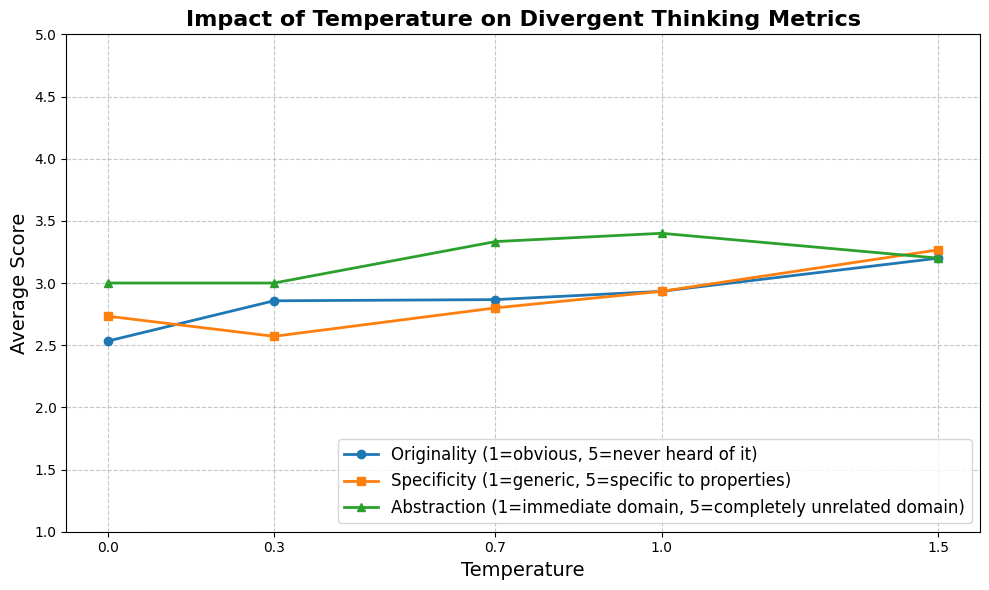

In [ ]:
# Load your manually graded data back into pandas
df_graded = pd.read_csv('/content/drive/MyDrive/NST2062 ownself/divergent_thinking_graded_v2.csv')

# Now you can easily group by temperature and get the averages!
averages = df_graded.groupby('temperature')[['originality', 'specificity', 'abstraction']].mean()
display(averages)

import matplotlib.pyplot as plt

# 2. Plotting the data
plt.figure(figsize=(10, 6))

# Plot each dimension as a separate line with distinct markers
plt.plot(averages.index, averages['originality'], marker='o', linewidth=2, label='Originality (1=obvious, 5=never heard of it)')
plt.plot(averages.index, averages['specificity'], marker='s', linewidth=2, label='Specificity (1=generic, 5=specific to properties)')
plt.plot(averages.index, averages['abstraction'], marker='^', linewidth=2, label='Abstraction (1=immediate domain, 5=completely unrelated domain)')

# 3. Formatting the chart to make it look professional
plt.title('Impact of Temperature on Divergent Thinking Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Temperature', fontsize=14)
plt.ylabel('Average Score', fontsize=14)

# Force the y-axis to show the full 1 to 5 grading scale
plt.ylim(1, 5)

# Ensure the x-axis ticks match your exact temperature steps
plt.xticks([0.0, 0.3, 0.7, 1.0, 1.5])

# Add a grid, legend, and display the plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='lower right')
plt.tight_layout()

# Save the figure to your folder and show it
plt.savefig('temperature_vs_creativity_scores.png')
plt.show()

#### [2] Lexical diversity (number of unique words / total words) as a function of temperature

I used data from the entire dataset of responses.

Lexical Diversity (Type-Token Ratio) per Temperature:


,full_text
temperature,
0.0,0.454114
0.3,0.439302
0.7,0.448096
1.0,0.486373
1.5,0.502265


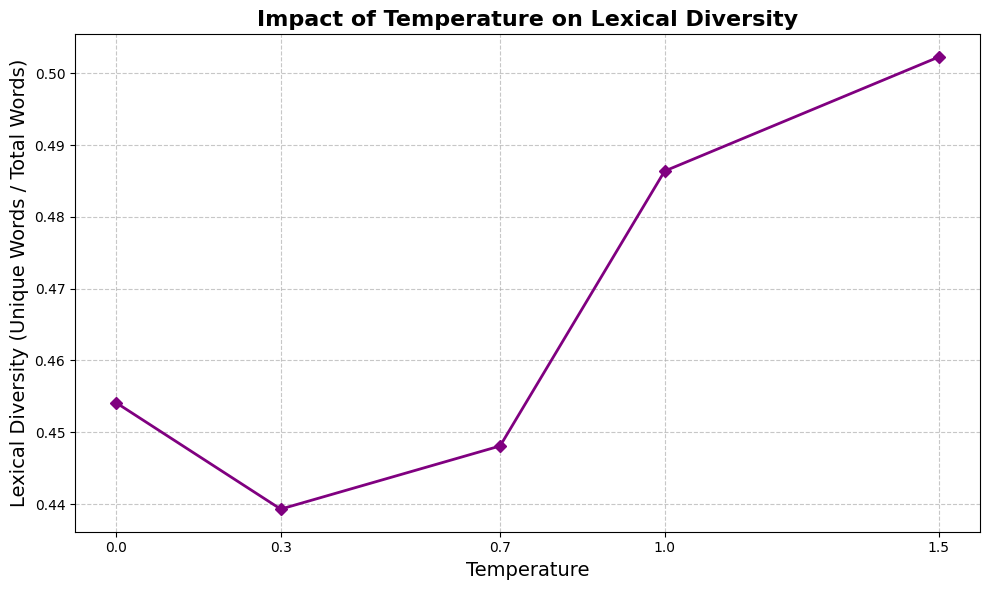

In [ ]:
import re
import matplotlib.pyplot as plt

# 1. Combine 'title' and 'explanation' into a single text column so we don't miss any words
divergent_thinking_results_full['full_text'] = divergent_thinking_results_full['title'].astype(str) + " " + divergent_thinking_results_full['explanation'].astype(str)

# 2. Define a function to calculate the unique words / total words
def calculate_lexical_diversity(text_series):
    # Join all text for this temperature into one massive string
    combined_text = " ".join(text_series)

    # Use regular expressions (re) to extract words.
    # \b\w+\b grabs only alphanumeric words and ignores punctuation like commas and periods.
    # .lower() ensures "The" and "the" are counted as the same word.
    words = re.findall(r'\b\w+\b', combined_text.lower())

    total_words = len(words)

    # Converting the list to a 'set' automatically removes all duplicates
    unique_words = len(set(words))

    # Calculate the ratio (prevent division by zero just in case)
    if total_words == 0:
        return 0
    return unique_words / total_words

# 3. Group by temperature and apply our function
lexical_diversity_scores = divergent_thinking_results_full.groupby('temperature')['full_text'].apply(calculate_lexical_diversity)

print("Lexical Diversity (Type-Token Ratio) per Temperature:")
display(lexical_diversity_scores)

# 4. Plot the results
plt.figure(figsize=(10, 6))

# We'll use a distinct color (purple) so it doesn't get confused with your previous chart
plt.plot(lexical_diversity_scores.index, lexical_diversity_scores.values, marker='D', color='purple', linewidth=2)

plt.title('Impact of Temperature on Lexical Diversity', fontsize=16, fontweight='bold')
plt.xlabel('Temperature', fontsize=14)
plt.ylabel('Lexical Diversity (Unique Words / Total Words)', fontsize=14)

# Keep the x-axis ticks perfectly aligned with your temperature variables
plt.xticks([0.0, 0.3, 0.7, 1.0, 1.5])

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and display the plot
plt.savefig('lexical_diversity_plot.png')
plt.show()

#### [3] Semantic diversity (average pairwise cosine distance between sentence embeddings) as a function of temperature

I used data from the entire dataset of responses.

Loading the SentenceTransformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calculating semantic distances (this might take a few seconds)...

Semantic Diversity (Average Cosine Distance) per Temperature:


,full_text
temperature,
0.0,0.816980
0.3,0.807704
0.7,0.813950
1.0,0.824008
1.5,0.811168


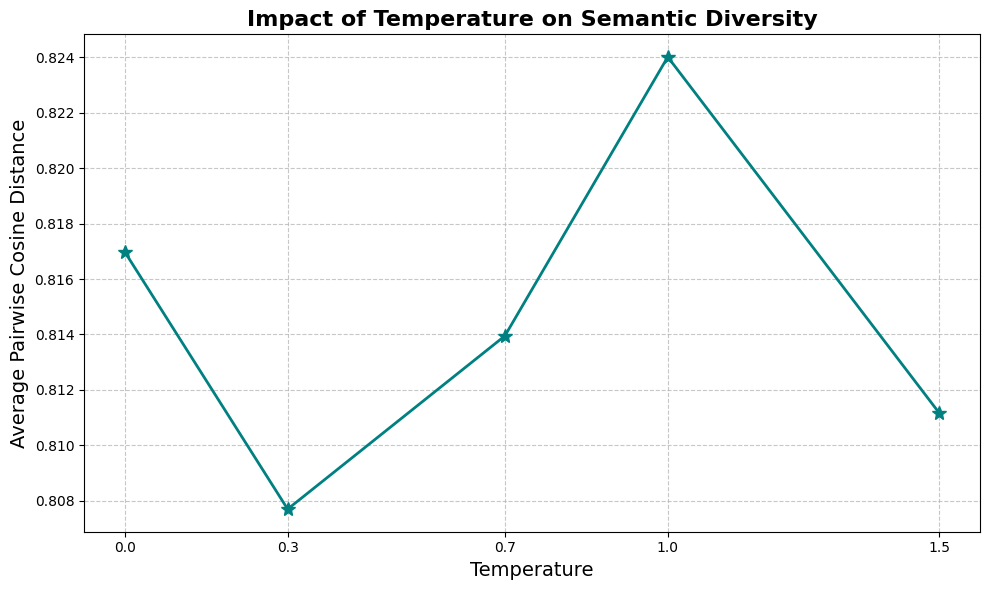

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances

# 1. Load the embedding model (this will download the model weights the first time)
print("Loading the SentenceTransformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Define our semantic diversity function
def get_average_cosine_distance(text_series):
    # Convert the pandas Series to a list of strings
    texts = text_series.tolist()

    # If there's less than 2 items, we can't calculate a pairwise distance
    if len(texts) < 2:
        return 0.0

    # Turn the text into mathematical vectors (embeddings)
    embeddings = model.encode(texts)

    # Calculate the distance between every single pair of uses
    # This creates a grid (matrix) where row 1, col 2 is the distance between use 1 and use 2
    distances_matrix = cosine_distances(embeddings)

    # We only want unique pairs (A to B). We don't want to count A to A (which is 0),
    # and we don't want to double count A to B and B to A.
    # np.triu_indices extracts just the unique pairs from the upper triangle of the matrix.
    n = distances_matrix.shape[0]
    unique_pairs = distances_matrix[np.triu_indices(n, k=1)]

    # Return the average distance of all those unique pairs
    return np.mean(unique_pairs)

print("Calculating semantic distances (this might take a few seconds)...")
# 3. Group by temperature and apply our function to the 'full_text' column we made earlier
semantic_diversity_scores = divergent_thinking_results_full.groupby('temperature')['full_text'].apply(get_average_cosine_distance)

print("\nSemantic Diversity (Average Cosine Distance) per Temperature:")
display(semantic_diversity_scores)

# 4. Plot the final results!
plt.figure(figsize=(10, 6))

# Using a distinct color (teal) and marker (star) for the grand finale (LOL gemini be cooking...)
plt.plot(semantic_diversity_scores.index, semantic_diversity_scores.values, marker='*', color='teal', markersize=10, linewidth=2)

plt.title('Impact of Temperature on Semantic Diversity', fontsize=16, fontweight='bold')
plt.xlabel('Temperature', fontsize=14)
plt.ylabel('Average Pairwise Cosine Distance', fontsize=14)

# Keep the x-axis ticks perfectly aligned
plt.xticks([0.0, 0.3, 0.7, 1.0, 1.5])

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and display
plt.savefig('semantic_diversity_plot.png')
plt.show()



---



### Part C: Detecting Mode Collapse (15 points)

Now test whether RLHF narrows the output distribution. Design an experiment:

1. **Repetition test**: Run the same prompt 10 times at temperature 0.7. How many of the 20 uses are **identical** across runs? How many are **semantically similar** (cosine similarity > 0.85)? A model in mode collapse will repeat itself; a diverse model won't.

2. **Safe vs. surprising**: Classify each use as **safe** (conventional, predictable — e.g., "use a brick as a doorstop") or **surprising** (unexpected, creative — e.g., "use a brick as a pillow to build character"). Plot the ratio of safe:surprising as a function of temperature.

3. **Compare models (if possible)**: If you have access to both a base model and an RLHF'd model (e.g., via different API endpoints or open-source models like Llama base vs. Llama-chat), compare their diversity at the same temperature. The prediction from Lecture 5: the RLHF'd model should be less diverse.

**Analysis questions** (answer in a markdown cell):
- At what temperature does the model produce the best balance of quality and originality?
- Is there evidence of mode collapse? Where?
- How does this connect to the exploration/exploitation tradeoff from the Decisions lecture?
- If you compared models: does RLHF reduce diversity as predicted?

#### C1. Repetition Test

In [ ]:
# [1] Repetition Test for sock

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from google import genai
from google.genai import types

# Initialize model
embedder = SentenceTransformer('all-MiniLM-L6-v2')

object_to_test = "sock"
num_runs = 10
temperature = 0.7
all_uses = []

print(f"Running repetition test for {object_to_test}...")

for run in range(num_runs):
    prompt = f"List 20 unusual uses for a {object_to_test}. Be creative and surprising. Number each use. Format as 'Title: Explanation'\n"

    config = types.GenerateContentConfig(temperature=temperature)
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=config
    )

    # Extract uses and clean them basic string splitting
    uses = [use.strip() for use in response.text.strip().split('\n') if use.strip() and use[0].isdigit()]
    for use in uses:
        clean_use = use.split(':', 1)[-1].strip() if ':' in use else use
        all_uses.append(clean_use)

# 1. Exact Repetition Test
unique_exact = len(set(all_uses)) # distinct elements (duplicates removed)
total_uses = len(all_uses) # all elements
exact_duplicates = total_uses - unique_exact

print(f"Total uses generated: {total_uses}")
print(f"Exact duplicates found: {exact_duplicates}")

# 2. Semantic Repetition Test (Cosine Similarity > 0.85)
embeddings = embedder.encode(all_uses)
similarity_matrix = cosine_similarity(embeddings)

# Extract upper triangle to avoid self-matching (1.0) and double counting
upper_triangle_indices = np.triu_indices(similarity_matrix.shape[0], k=1)
similarity_scores = similarity_matrix[upper_triangle_indices]

# Count pairs with similarity > 0.85
highly_similar_pairs = np.sum(similarity_scores > 0.85)
print(f"Semantically similar pairs (> 0.85): {highly_similar_pairs}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running repetition test for sock...
Total uses generated: 200
Exact duplicates found: 0
Semantically similar pairs (> 0.85): 60


I ran the above code several times and these are my results

| Run Trial | Number of exact duplicates | Number of semantically similar pairs
|---|---|---|
| 1 | 19 | 242|
| 2 | 0 | 74 |
| 3 | 0 | 50 |
| 4 | 0 | 56 |
| 5 | 0 | 60 |

With the number of semantically similar pairs, I do a hypothesis test to see if this number of pairs is significant. Assuming a human baseline has 1% similarity, I will assume a fully divergent model to be 1%.

In [ ]:
# Hypothesis testing

import scipy.stats as stats

def calculate_collapse_metrics(highly_similar_pairs, total_uses=200, baseline_rate=0.01):
    """
    Calculates the percentage of collapse and tests it against a theoretical baseline.
    baseline_rate: The expected percentage of overlapping ideas from a healthy/human
                   baseline (default 0.01 = 1%)
    """

    # 1. Calculate Total Possible Pairs
    # Formula: (N * (N - 1)) / 2
    total_pairs = int((total_uses * (total_uses - 1)) / 2)

    # 2. Calculate Percentage of Similarity
    percentage = (highly_similar_pairs / total_pairs) * 100

    # 3. Calculate P-value using a Binomial Test
    # H0 (Null Hypothesis): The AI's repetition rate is just the standard 1% baseline.
    # H1 (Alternative): The AI's repetition rate is significantly greater than 1% (Mode Collapse).
    test_result = stats.binomtest(
        k=highly_similar_pairs,
        n=total_pairs,
        p=baseline_rate,
        alternative='greater'
    )
    p_value = test_result.pvalue

    # Print the formal statistical report
    print("-" * 40)
    print("MODE COLLAPSE STATISTICAL REPORT")
    print("-" * 40)
    print(f"Total Uses Generated: {total_uses}")
    print(f"Total Possible Pairs: {total_pairs:,}")
    print(f"Highly Similar Pairs (>0.85): {highly_similar_pairs}")
    print(f"Percentage of Similarity: {percentage:.3f}%\n")

    print(f"Statistical Test: Binomial Test (Alternative = 'greater')")
    print(f"Assumed Healthy Baseline: {baseline_rate * 100}% overlap")
    # We format the p-value in scientific notation because it will likely be extremely small
    print(f"P-value: {p_value:.2e}")

    print("-" * 40)
    if p_value < 0.05:
        print("VERDICT: STATISTICALLY SIGNIFICANT (p < 0.05)")
        print("We reject the null hypothesis. The model exhibits mathematically")
        print("significant mode collapse compared to a diverse baseline.")
    else:
        print("VERDICT: NOT SIGNIFICANT (p >= 0.05)")
        print("The model's repetition rate is within the expected baseline variance.")
        print("No severe mode collapse detected.")

# Example usage using your previous output:
# If you saved your previous results to variables, just plug them in here!
my_similar_pairs = 60
my_total_uses = 200     # 10 runs * 20 uses

calculate_collapse_metrics(my_similar_pairs, my_total_uses, baseline_rate=0.01)

----------------------------------------
MODE COLLAPSE STATISTICAL REPORT
----------------------------------------
Total Uses Generated: 200
Total Possible Pairs: 19,900
Highly Similar Pairs (>0.85): 60
Percentage of Similarity: 0.302%

Statistical Test: Binomial Test (Alternative = 'greater')
Assumed Healthy Baseline: 1.0% overlap
P-value: 1.00e+00
----------------------------------------
VERDICT: NOT SIGNIFICANT (p >= 0.05)
The model's repetition rate is within the expected baseline variance.
No severe mode collapse detected.


In [ ]:
# for my other trial which gave 242 semantically similar pairs
my_similar_pairs = 242
my_total_uses = 200

calculate_collapse_metrics(my_similar_pairs, my_total_uses, baseline_rate=0.01)

----------------------------------------
MODE COLLAPSE STATISTICAL REPORT
----------------------------------------
Total Uses Generated: 200
Total Possible Pairs: 19,900
Highly Similar Pairs (>0.85): 242
Percentage of Similarity: 1.216%

Statistical Test: Binomial Test (Alternative = 'greater')
Assumed Healthy Baseline: 1.0% overlap
P-value: 1.64e-03
----------------------------------------
VERDICT: STATISTICALLY SIGNIFICANT (p < 0.05)
We reject the null hypothesis. The model exhibits mathematically
significant mode collapse compared to a diverse baseline.


The RLHF model exhibited high variance in its mode collapse. In one trial, it suffered severe mode collapse (242 highly similar pairs, p <.05). However, in another trial, it exhibited exceptional diverge, overlapping only 60 times (0.3%, p = 1.0). This outperforms the theoretical human baseline. This suggests that while RLHF restricts the overall creative space, the model can still occassionally find highly divergent paths depending on the stochastic seed and the specific object's affordances.

#### C2. Safe vs Surprising Test

Using the same samples from part A, I manually classified each response as either 1-Surprising or 0-Safe. I choose to do manual classification as LLM can be inconsistent when judging their own creativity.

Ratio of Surprising Ideas per Temperature:


,temperature,Surprising_Ratio
0,0.0,0.266667
1,0.3,0.266667
2,0.7,0.200000
3,1.0,0.466667
4,1.5,0.600000


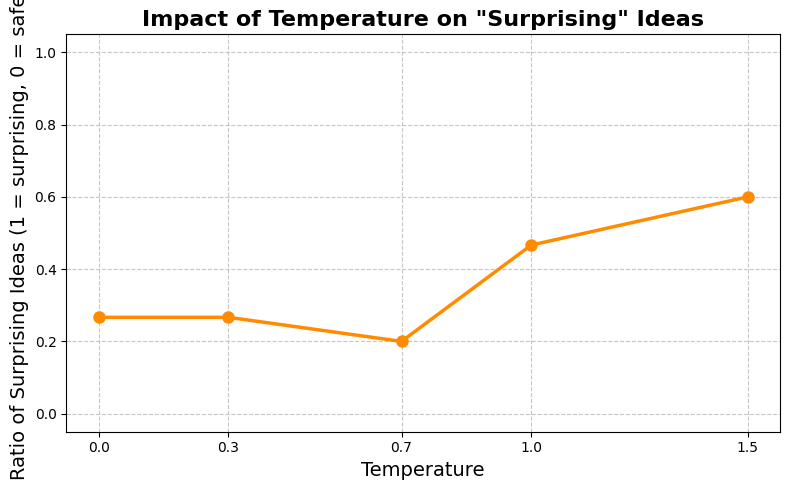

In [ ]:
# [2] safe vs suprising classification

import pandas as pd
import matplotlib.pyplot as plt

# 1. Load manually classified dataset
df_classified = pd.read_csv('/content/drive/MyDrive/NST2062 ownself/divergent_thinking_safesurprising.csv')

# 2. Calculate the ratio of surprising ideas per temperature
# Because 1 = surprising and 0 = safe, the mean() perfectly calculates the ratio!
surprising_ratio = df_classified.groupby('temperature')['surprising'].mean()

print("Ratio of Surprising Ideas per Temperature:")
display(surprising_ratio.reset_index(name='Surprising_Ratio'))

# 3. Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(
    surprising_ratio.index,
    surprising_ratio.values,
    marker='o',
    color='darkorange',
    linewidth=2.5,
    markersize=8
)

# Formatting the chart
plt.title('Impact of Temperature on "Surprising" Ideas', fontsize=16, fontweight='bold')
plt.xlabel('Temperature', fontsize=14)
plt.ylabel('Ratio of Surprising Ideas (1 = surprising, 0 = safe)', fontsize=14)

# Keep the x-axis ticks perfectly aligned with your temperature variables
plt.xticks([0.0, 0.3, 0.7, 1.0, 1.5])

# Force the y-axis to show the full 0.0 to 1.0 ratio scale
plt.ylim(-0.05, 1.05)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the figure to your folder and show it
plt.savefig('safe_vs_surprising_plot.png')
plt.show()

The surprising vs safe test reveals a positive correlation, with more surprising responses at higher temperatures.

While the general upward trend of 'Surprising' uses correlated with higher temperatures as expected, I was surprised the baseline ratio at Temperature 0.0 was ~0.3 (rather than theoretical 0.0). This highlights a core limitation of the human-in-the-loop evaluation: subjective bias. My classification of 'Safe' vs 'Surprising' depended heavily on my prior knowledge and affordance threshold. Furthermore, because the prompt explicitly requested for "unusual uses", the model's most deterministic outputs (Temperature 0.0) could still contain concepts that met my subjective threshold for surprise.

#### Analysis of model collapse detection



**Q1. At what temperature does the model produce the best balance of quality and originality?**

Based on the empirical data from the safe vs surprising classification, the ideal temperature for quality and originality occurs at temperature 1.0. At lower temperatures (0.0 to 0.3), the ratio of surprising ideas stagnates around 27%. Interestingly, at 0.7 temperature, the ratio of surprising ideas dipped to 20%, suggesting the model was struggling against its alignment constraints. Perhaps it was exploring just enough to leave the baseline but got trapped, so the ratio dropped. It was only at 1.0 temperature that the model successfully broke past these constraints, nearly doubling its ratio (~47% surprising). While temperature 1.5 yielded the highest raw originality, qualitative observation shows that extreme temperatures often degrade into unusuable, impractical responses. Hence, I arrive at 1.0 temperature as the optimal balance of coherence and creativity.

**Q2. Is there evidence of mode collapse? Where?**

Yes, there is evidence for mode collapse, at temperature 0.7. In the repetition test at 0.7, one trial generated 19 duplicate responses and 242 semantically similar pairs (cosine similarity > 0.85) out of 19,900 possible combinations. This gives a percentage similarity of 1.216%, which is significantly higher than the assumed baseline diversion of 1% (p <.05). Notably, this was just one trial out of the total 5 trials conducted that gave such evidence, thereby pointing out the variability of high variance in mode collapse as well.  

Regardless, this mode collapse could explain the anomaly in the safe vs surprising classification, where the surprising ratio temporarily dropped to 20% at 0.7. The model, trapped in a high-probability mode of heavily reinforced RLHF approved 'safe' concepts, ended up looping through conventional ideas rather than freely exploring the latent space.


**Q3. How does this connect to the exploration/exploitation tradeoff from the Decisions lecture?**

The temperature parameter is a dial for the exploration/exploitation tradeoff.
The decision making lecture frames creativity as decision-making, in a space of things that may not exist yet, achieved by sampling from a distribution of already known data.

At low temperatures, the model acts as a reward-maximiser. It exploits the highest probability and most conventional tokens in its latent space. It penalises unusual outputs because annotators preferred familiar confident responses. Hence, it would give more safe answers.

At high temperatures, the model is forced to take risks and sample lower probability tokens. This allows them to venture further into the latent space to generate genuine novelty.

It is a tradeoff because the model will either prioritise exploiting higher probabilities and rewards, thereby giving safe answers, or explore deeper into the lower probabilities, giving more surprising answers.

### Bonus: The Audience Matters (10 bonus points)

**Course connection**: Mentalising (Lecture 6) — creativity needs an audience.

Add audience context to the prompt and measure whether it changes the outputs:
> "List 20 unusual uses for a brick. Your audience is [a group of 5-year-olds / a panel of art critics / a team of engineers / a comedy club audience]."

For each audience:
1. Run at temperature 0.7
2. Score using your rubric
3. Measure how the output distribution shifts

**Analysis**: Does the model adapt its creativity to the audience? Is it doing something like mentalising — modelling what each audience would find creative? Or is it just pattern-matching on audience-associated vocabulary?

In [ ]:
import pandas as pd
import re
import time
import matplotlib.pyplot as plt
from openai import OpenAI # pip install openai

# 1. Initialize the OpenAI client
OPEN_API_KEY = userdata.get('openkey')
client = OpenAI(api_key=OPEN_API_KEY)

audiences = [
    "a group of 5-year-olds",
    "a panel of art critics",
    "a team of engineers",
    "a comedy club audience"
]

all_results = []

# --- 2. GENERATION FUNCTION ---
def generate_uses(audience):
    prompt = f"List 20 highly unusual uses for a brick. Your audience is {audience}. Output only a numbered list."

    print(f"Generating for: {audience}...")
    try:
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.7
        )
        # Parse the numbered list
        uses = re.findall(r'\d+\.\s*(.*)', response.choices[0].message.content)
        return uses
    except Exception as e:
        print(f"API Error during generation: {e}")
        return []

for audience in audiences:
    print(f"Generating for: {audience}...")
    uses = generate_uses(audience)
    all_results.extend([{"Audience": audience, "Use": use} for use in uses])
    time.sleep(2)


In [ ]:
# --- EXPORT TO CSV ---
df_audience_all = pd.DataFrame(all_results)

# sample 10
df_audience = df_audience_all.groupby(['Audience']).sample(n=10, random_state=42)

# Save file
csv_filename = 'audience_mentalising_sample5_graded.csv'
df_audience.to_csv(csv_filename, index=False)

In [ ]:
df_audience_graded = pd.read_csv('/content/drive/MyDrive/NST2062 ownself/audience_mentalising_sample5_graded.csv')

averages = df_audience_graded.groupby('Audience')[['originality', 'specificity', 'abstraction', 'surprising']].mean()
display(averages)

,originality,specificity,abstraction,surprising
Audience,,,,
a comedy club audience,3.6,2.8,3.5,0.7
a group of 5-year-olds,3.5,2.5,3.5,0.7
a panel of art critics,2.7,2.4,3.0,0.4
a team of engineers,2.1,3.2,3.2,0.2


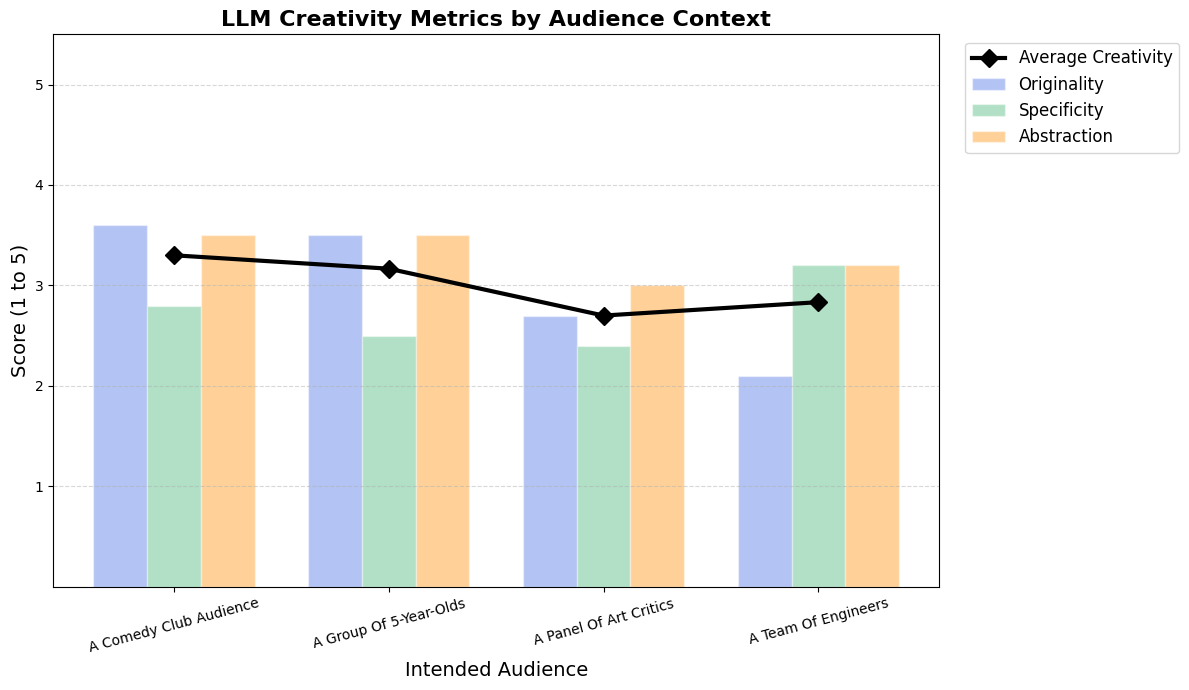

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure 1-5 columns are actually numeric
for col in ['originality', 'specificity', 'abstraction']:
    df_audience_graded[col] = pd.to_numeric(df_audience_graded[col], errors='coerce')

# 2. Calculate the "Average Creativity" metric (mean of the 3 individual metrics per row)
df_audience_graded['Average_Creativity'] = df_audience_graded[['originality', 'specificity', 'abstraction']].mean(axis=1)

# 3. Aggregate data: Calculate the mean for each metric across the 5 samples per Audience
metrics_to_plot = ['originality', 'specificity', 'abstraction', 'Average_Creativity']
agg_df = df_audience_graded.groupby('Audience')[metrics_to_plot].mean()

# Set up the X-axis positions
audiences = agg_df.index
x = np.arange(len(audiences))

# 4. Plotting
fig, ax = plt.subplots(figsize=(12, 7))

# We use grouped bars with a low alpha (translucency) to satisfy your overlap requirement
bar_width = 0.25

# Originality (shifted left)
ax.bar(x - bar_width, agg_df['originality'], width=bar_width,
       color='royalblue', alpha=0.4, edgecolor='white', label='Originality')

# Specificity (centered)
ax.bar(x, agg_df['specificity'], width=bar_width,
       color='mediumseagreen', alpha=0.4, edgecolor='white', label='Specificity')

# Abstraction (shifted right)
ax.bar(x + bar_width, agg_df['abstraction'], width=bar_width,
       color='darkorange', alpha=0.4, edgecolor='white', label='Abstraction')

# 5. Overlay the Final Average Creativity as a bold, solid line
ax.plot(x, agg_df['Average_Creativity'], color='black', marker='D', markersize=9,
        linewidth=3, label='Average Creativity')

# 6. Formatting the chart
ax.set_title('LLM Creativity Metrics by Audience Context', fontsize=16, fontweight='bold')
ax.set_xlabel('Intended Audience', fontsize=14)
ax.set_ylabel('Score (1 to 5)', fontsize=14)

# Set the X-ticks to be the names of the audiences
ax.set_xticks(x)
ax.set_xticklabels([str(a).title() for a in audiences], rotation=15)

# Lock the Y-axis to your 1-5 grading scale
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])

# Add a subtle grid for easier reading
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Place the legend cleanly outside the plot area
ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig('audience_manual_grading_results.png')
plt.show()

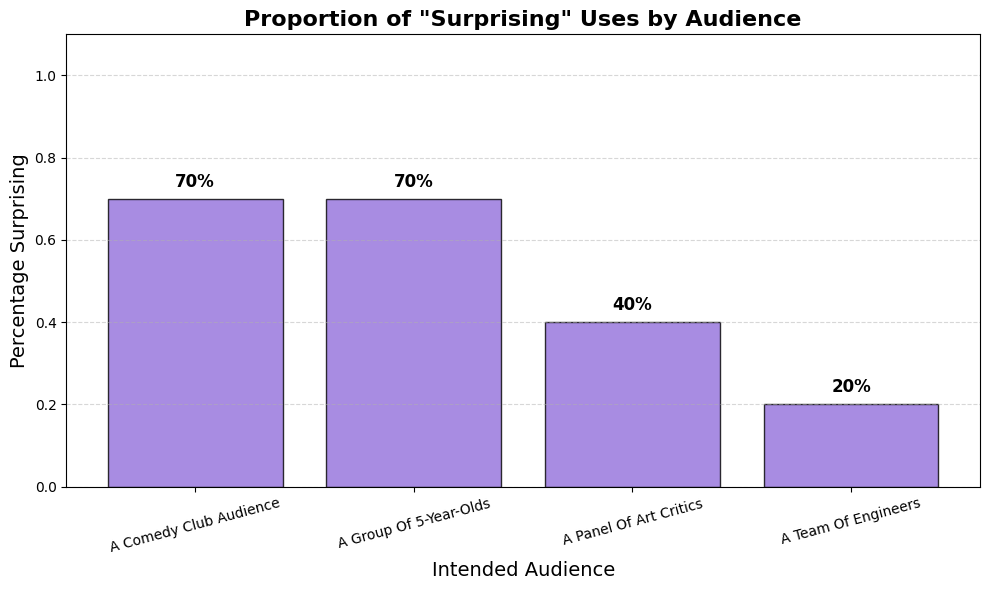

In [ ]:
# For the added column classifying whether responses are safe or surprising

# Ensure the 'surprising' column is numeric
df_audience_graded['surprising'] = pd.to_numeric(df_audience_graded['surprising'], errors='coerce')

# 2. Calculate the Ratio of Surprising uses per Audience
# The mean of a 1/0 column gives the exact ratio (e.g., three 1s and two 0s = 0.60 or 60%)
surprising_ratio = df_audience_graded.groupby('Audience')['surprising'].mean()

# 3. Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Plot a clean bar chart
bars = ax.bar(surprising_ratio.index.str.title(), surprising_ratio, color='mediumpurple', edgecolor='black', alpha=0.8)

# 4. Formatting the chart
ax.set_title('Proportion of "Surprising" Uses by Audience', fontsize=16, fontweight='bold')
ax.set_xlabel('Intended Audience', fontsize=14)
ax.set_ylabel('Percentage Surprising', fontsize=14)

# Format the Y-axis as percentages
ax.set_ylim(0, 1.1) # Set a bit higher than 1.0 to leave room for labels

# Rotate the X-axis labels so they don't overlap
plt.xticks(rotation=15)

# 5. Add the exact percentages on top of each bar for clarity
for bar in bars:
    height = bar.get_height()
    # Only print the text if the height is greater than 0
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height*100:.0f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Subtle grid
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('audience_surprising_ratio.png')
plt.show()

In [ ]:
print("\n--- VOCABULARY SHIFT EXAMPLES ---")
for audience in audiences:
    sample = df_audience_graded[(df_audience_graded['Audience'] == audience)]['Use'].head(5).tolist()
    print(f"\n{audience.upper()}:")
    for s in sample:
        print(f"- {s}")


--- VOCABULARY SHIFT EXAMPLES ---

A COMEDY CLUB AUDIENCE:
- Use it as a makeshift dumbbell for brick lifting workouts.
- Use it as a makeshift ice pack for injuries.
- Use it as a makeshift bookend for your library.
- Play a game of brick juggling (Disclaimer: not recommended for beginners).
- Use it as a makeshift phone stand for hands-free video calls.

A GROUP OF 5-YEAR-OLDS:
- A book for telling stories with pictures.
- A telescope for spotting shooting stars
- A bridge for helping toy cars cross a river
- A spaceship for exploring outer space
- A pretend piece of cake for a teddy bear tea party

A PANEL OF ART CRITICS:
- Prop for a photography shoot
- Building material for a non-traditional structure
- Sculpture base
- Doorstop
- Canvas for graffiti art

A TEAM OF ENGINEERS:
- Use as a makeshift dumbbell for weightlifting exercises
- Create a makeshift bird bath or feeder
- Use as a makeshift bookend
- Use as a makeshift anchor for a small boat
- Use as a makeshift tent anchor f

#### Analysis

**Does the model adapt its creativity to the audience? Is it doing something like mentalising — modelling what each audience would find creative? Or is it just pattern-matching on audience-associated vocabulary?**

Yes, the model adapts its 'creativity' to the audience. The responses for 5 year olds and comedy club scored consistently higher in originality and abstraction. For the team of engineers, responses are heavily skewed towards practical, unoriginal and conventional uses. This happened even with the temperature set to an exploratory 0.7. The semantic weight of the word "engineer" anchored the model to the "safer", "highly probably regions of its latent space. Similarly, the 'art critic" prompt constrained the model's search space almost exclusively to art-related concepts (eg. sculptures, DIY projects), which limited the variability and true originality of its responses.

I doubt this is sufficient evidence for mentalising. Theory of Mind true mentalising requires building an internal model of another entity's beliefs, knowledge gaps and emotional expectations. I think the model instead does pattern matching on the audience-vocabulary it was trained with. The LLM does not possess an internal model of what a 5 year old or art critic actually thinks or feels. Instead, the prompt acts as an attention mechanism that shifts the conditional probability distribution towards semantic clusters associated with that audience in its training data. For example, the model knows that words like "tea party" and "stars" frequently co-occur with "children" in the lexical space, so it traverses to that specific linguistic neighbourhood.

I doubt this is a good study to test for mentalising. Instead, I think it demonstrates the illusion of mentalising, where pure linguistic competence and vocabulary-matching can mimic audience awareness. To test if the model is mentalising the audience's creativity, I think it needs to use frameworks like the Sally-Anne test to see if the model can mentalise crativity. The lecture on mentalising taught me that LLMs fail at “strange stories” that require real-world inference (eg understanding white lies, misunderstandings, double bluffs, irony). Thus, if the model could identify white lies (for example), the model could be evaluated as being able to mentalise creativity.

For example, maybe the model can be given asymmetrical information, with this prompt: "Alice and Bob secretly know that the expensive new 'avant-garde' sculpture in the office lobby is actually just a broken piece of the HVAC system that fell through the ceiling. Carol (the boss) is very proud of it and believes it is a masterpiece by a famous artist. Write a short, creative toast that Alice can give at the sculpture's unveiling. The toast must sound like a completely sincere, beautiful compliment to Carol, but it must contain a hidden joke about air conditioning or broken pipes that only Bob will realize is funny." Here, the model cannot just pull words that are associated with "art critic" or "comedy" words. It has to navigate Carol's false belief that it is art, and Bob's true knowledge that it's trash, simultaneously. If the toast gives the secret away to Carol, it fails. If Bob doesn't get the joke, it fails. So, the LLM needs to mentalise the dual-audiences and come up with a creative response.
* [Sidenote: This idea came up after chatting with Gemini about what is a good experiment to test for mentalising people's creativity. I thought Gemini's suggestion was pretty creative! Either someone wrote a paper about how to test this before or AI came up with this itself. My continued chat with Gemini reveals that it did rely on past research, with Herbert H. Clark's theory on audience design and common ground, where the speaker constantly models the listener's mental state, with irony and sacarsm as the stress tests for this. It also brought up Lombardi and Lenci's (2025) study on rethinking theory of mind simulation in LLMs, where researchers gave LLMs scenarios to test if it can mentalise the characters and select actions based on belief attribution. Such ironies seem to stumble LLMs and show evidence against mentalising. I thought it's a cool study! but I shall not yap more otherwise your attention will be dwindling and lost in the middle failure mode hits haha]

### 🪞 Metacognitive Reflection — Problem 2 (graded, 5 points included above)

Write 200–400 words answering these questions. **This must be in your own voice — not generated by an LLM.**

1. What was the hardest part of designing a creativity rubric? What did it teach you about the evaluation problem?
2. Did the temperature results match your predictions? What surprised you?
3. Did you find evidence of mode collapse? If yes, is this a problem — or is it the model being appropriately safe?
4. How did you use LLMs during this problem? Be specific about what you prompted for and what you had to do yourself.
5. Connect your findings to the course: if creativity is search through representation space, and temperature controls the search width, what does your data tell you about the shape of that space?

The hardest part of designing a creativity rubric is (ironically) finding metrics that are creative enough. I struggled to balance utility with originality. Initially, I used “practicality” and “humour”, but many practical ideas were not creative, and the highly original ones seemed impractical. For example, I noted that some of the concepts of some responses, like using a bag to make an artistic stencil, can be repeated for other items (like paper), so I wanted to penalise the creativity metric for giving responses that are not unique to the item. But this meant changing the rubric again. I reiterated and went through some examples of the responses, to see what responses surprised me and which ones were 'meh'. For example, if the model treats the bag like a container (a cloud in the bag experiment), then I find it not creative too. Interestingly, the LLM suggested using pollen from flowers as a lubricant for precision clockwork or optical mechanisms. I assumed this was impractical and wanted to rate it low, but a Google search proved it viable. The LLM’s knowledge surpassed my limited knowledge to confidently evaluate whether it would work, and I did not think I could grade its practicality properly. I also thought that LLM might just be using literature research on flowers already available to come up with this idea, and thus cannot be a sign for creativity. This was also why I removed practicality from my metric on creativity (Gemini reminds me that this is the scalable oversight problem, where AI systems have become so advanced that humans can no longer evaluate it). Hence, it is difficult to evaluate and design a creativity rubric when my human knowledge is limited in what ideas are already out there, while LLM has access to a vast database of ideas online, and could easily tap into either ideas online and may not be in itself creative--which I cannot evaluate since I do not have access to that database. Anyways, it is either my metrics are terrible to differentiate creativity, or my evaluation is inconsistent and TOO subjective, or the responses just isn't that great.

Temperature results matched my prediction. I predicted that higher temperatures would yield more “surprising” results, which was generally true, and lexical diversity increased dramatically. However, I was surprised that there was a drop at temperature 0.3 for both lexical and semantic diversity. Was that a glitch? Or maybe it just so happen to traverse a peak with high probability safe answers. I was also surprised that at temperature 1.5, when there was the highest lexical diversity, there was a huge drop for semantic diversity. I thought higher temperatures would correlate with higher lexical and semantic diversity. I wonder if it is because the model compensates and uses more lexically diverse words to meet creativity criterias, when it actually means the same thing.

I found highly variable evidence of mode collapse. My first run found 19 exact duplicates and 242 semantically similar pairs (p<.05). Subsequent runs gave 0 exact duplicates, with 74 and 60 semantically similar pairs (0.3%, p = 1.0). Since only the first run had evidence of mode collapse, it suggests that the RLHF’s model collapse is inconsistently present. At best, it exhibits significant semantic repetition (~50 pairs) that a human would not. Since the AI is generating 50 overlapping concepts across 10 repetitions, this shows that AI is still heavily relying on high-probability, safe answers rather than truly diverging into the unknown. Hence, I suppose it tries to be appropriately safe, but crashes out once it reaches its borderline and mode collapses.

I used Gemini to write and debug my code, while I handled all the manual grading. I also used LLM as a tutor to explain concepts I was struggling with, such as the mechanics of temperature, the definition of mode collapse, and the cognitive concept of object affordances, which later helped me explain why part c gave different results for each run. Gemini explained to me the concept of model collapse, how gpt-4 was trained on a quirky wider spread of human data. Gpt-5 is trained with 50% being data from older models. So those at the edges get left out, leaving less creative responses.

If creativity is a search through representation space, and temperature controls the search width, I think this space is shaped like a topographical map. The safe, conventional answers (eg using socks to store items) sit at the highest probability peaks. Increasing the temperature widens the search, forcing the model off the mountain peaks and deeper into valleys of bizarre yet highly creative concepts. RLHF also artificially sharpens those peaks to keep the model appropriately safe and predictable,  making the wide broad mountains into narrow peaks, so the model seeks to hit the narrow peaks rather than explore the rest of the mountain. Yet, this is also a tradeoff in making the model safe, thus resulting in the mode collapse and crushing creativity.

And if this is so, then the Pastiche Problem holds. Interpolation in latent space is not genuinely creative but just a sophisticated collage, with the model traversing through peaks and valleys. It is not truly creative since it is not possible to (or very difficult) to transform the underlying structure to reveal transformational creativity.


---
## Grading Summary

| Component | Points |
|---|---|
| **Problem 1** | |
| Part A: Calibration dataset | 10 |
| Part B: Your own calibration | 10 |
| Part C: Model calibration + comparison | 15 |
| Part D: Prompt interventions | 10 |
| Bonus: Token-level probabilities | (+10) |
| **Problem 2** | |
| Part A: Divergent thinking experiment | 10 |
| Part B: Creativity rubric + metrics | 10 |
| Part C: Mode collapse detection | 15 |
| Bonus: Audience experiment | (+10) |
| **Metacognitive Reflections** | |
| Reflection 1 (included in P1) | (5 of P1) |
| Reflection 2 (included in P2) | (5 of P2) |
| **Total** | **80 + 20 bonus** |

---

### Assessment Criteria

**Code quality** (30%): Does the code run? Is it clean and documented? Are the experiments reproducible?

**Analysis quality** (40%): Are the visualisations clear? Are the comparisons meaningful? Do the analysis questions receive thoughtful, evidence-based answers that connect to course concepts?

**Metacognitive reflections** (20%): Are the reflections genuine, specific, and self-aware? Do they demonstrate learning — not just completion?

**Rigour** (10%): Sample sizes, statistical thinking, awareness of limitations. You don't need p-values, but you should know when your sample is too small to draw strong conclusions.

---

### A Note on Using LLMs

You will use LLMs both as a **tool** (to help you code) and as the **object of study** (the thing you're investigating). This is intentional. The metacognitive reflections ask you to distinguish between these two roles. The ability to use a tool critically while simultaneously studying it is a core skill for working with AI systems — and it's a form of mentalising: modelling the capabilities and limitations of a non-human agent you're interacting with.

Have fun! I am looking forward to see your results!